# Transmon-controlled beamsplitter between two cavities, from two detuned sidebands

**Q1** — transmon (Duffing).  **C1**, **C2** — linear cavities.
Tensor order **C1 $\otimes$ C2 $\otimes$ Q1**.

Rates are angular frequencies in rad/µs, so dividing by $2\pi$ reads out in MHz and every
time is in µs.  Pulse edges are raised-cosine (Hann), so the envelope is $C^1$.

### The scheme

Both pumps sit on the same transmon sideband — by default $|e,1\rangle-|f,0\rangle$ —
cavity 1 at detuning $d_1$, cavity 2 at $d_2$.  Because there is **no static $\chi$**, the
sideband $|e,n\rangle-|f,n{-}1\rangle$ is resonant for every $n$, so the mechanism is
photon-number independent by construction.  That is the whole point, and it is why
everything below is scored up to a total photon number rather than in the single-photon
sector.

Adiabatically eliminating the transmon leaves a cavity–cavity interaction whose strength
depends on the transmon state.  It arrives with an unavoidable companion: a **conditional
photon-number phase locked at exactly half the beamsplitter angle**.  Removing that phase
is what the echo is for, and it is the central design problem here.

### The gate we are building

$$\boxed{\ U_\mathrm{target}=\exp\left[-i\frac{\theta}{2}\,P_e\left(a_1^\dagger a_2+a_2^\dagger a_1\right)\right]\ }\qquad P_e=|e\rangle\langle e|$$

i.e. $\mathrm{BS}(\theta)$ on the cavities when Q1 is in $|e\rangle$, identity when it is in
$|g\rangle$, with $\theta=\pi/2$ for 50:50.  Since $P_e=(1+\sigma_z)/2$ this is the same as

$$P_eG=\tfrac12G+\tfrac12\sigma_zG,\qquad G\equiv a_1^\dagger a_2+a_2^\dagger a_1$$

so the $P_e$ generator and the $\sigma_z$ generator differ by an **unconditional**
beamsplitter of half the angle.  The pulse natively produces the $\sigma_z$ form, so the
$P_e$ gate is that sequence followed by one unconditional $\mathrm{BS}(\theta/2)$ — a real
cavity–cavity pulse whose angle is known in closed form.  Both are scored below so the cost
of that last pulse is visible.

### What each task does

| task | question |
|---|---|
| **1** | Chevron: sweep $d_2$ and time with Q1 in $g$ / $e$, for $\vert n,0\rangle$, $n=1\dots4$. Does the exchange happen at the same detuning *and the same rate* for every $n$? |
| **2** | The conditional 50:50 beamsplitter: echo, calibrate, score against photon number. |
| **3** | Echo variants — the phase flip on/off, and the two-tone ($ef$ then $ge$) echo. |

### Conventions and assumptions

* **One place to edit.** The second cell has a clearly marked knobs panel — `ALPHA`, `G`,
  `D`, `SIGMA`, `NC`, `NQ`, `PARK`. Every task is written in terms of those names and
  contains no bare physical numbers, so changing one and re-running from that cell down
  changes the whole notebook. Sweep ranges and grids are derived too, so they stay sensible.
* **No nonzero defaults.** Every physical parameter in `DEFAULTS` is zero; the only nonzero
  defaults are the truncations and the slice count, which cannot be zero. Nothing physical
  is ever silently assumed — the knobs panel is the only source.
* The $\pi$ pulses are instantaneous and exactly the identity on $|f\rangle$; there is no
  decay or dephasing.
* A residual static $\chi$ is available as a knob (`chi1`, `chi2`) and is zero everywhere
  below, so the photon-number-independence claim can be stress-tested.

## Notation

| symbol | code | meaning |
|---|---|---|
| $N_c$, $N_q$ | `Nc`, `Nq` | Fock truncation per cavity ($0\dots N_c-1$); transmon levels kept |
| $\alpha$ | `alpha` | transmon anharmonicity, $\alpha=\omega_{ef}-\omega_{ge}<0$ |
| $g_1,g_2$ | `g1`, `g2` | activated sideband rates; each $\propto$ its pump amplitude |
| $d_1,d_2$ | `d1`, `d2` | detuning of each pump from the **parked** sideband |
| $\Delta\phi$ | `phi2 - phi1` | relative pump phase — the only physical combination |
| $\sigma$ | `sigma` | pump edge parameter; each raised-cosine edge occupies $2\sigma$ ($\sigma=0$ is square) |
| $\theta_j$ | `theta1`, `theta2` | rotating-frame cavity detuning, $\theta_j=-\alpha+d_j$ ($ef$ parking) |
| $k$ | — | transmon level index, $k=0,1,2,3$ for $g,e,f,h$ |
| $N$ | `N` | total cavity photon number $n_1+n_2$ |
| $G$ | `G` | exchange (beamsplitter) operator $a_1^\dagger a_2+a_2^\dagger a_1$ |
| $\sigma_z$ | `o["P"][1] - o["P"][0]` | $|e\rangle\langle e|-|g\rangle\langle g|$ on the transmon |
| $\delta_k$ | `rung_delta` | detuning of the sideband rung $\vert k\rangle\to\vert k{+}1\rangle$ |
| $c_k$ | `c_level`, `c_levels` | second-order coefficient on transmon level $k$ |
| $\varepsilon_e$ | `lamb_shift` | differential Lamb shift on $\vert e\rangle$ |
| $\chi_k$ | `chi_levels` | $=g^2c_k$, the rate on level $k$ |
| $\delta\chi$ | `dchi` | $=\chi_e-\chi_g$, the **conditional** rate — the figure of merit |
| $\theta$ | `THETA2` | conditional beamsplitter angle; $\pi/2$ is 50:50 |
| $A$, $B$ | `branch_angles` | photon-number phase and beamsplitter angle on one branch |
| $T$ | `T` | total gate duration, ramps included |
| $n_\mathrm{max}$ | `nmax` | fidelity is scored on $n_1+n_2\le n_\mathrm{max}$ |
| $P$, $D$ | `P`, `P.tr()` | projector onto that subspace, and its dimension |
| $\mu_1,\mu_2,\mu_q$ | `mu` | virtual-Z angles, one global phase per mode (free) |
| $\mathrm{BS}(\theta/2)$ | `beamsplitter` | unconditional cavity–cavity beamsplitter — a real pulse, not free |

In [1]:
import time
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import erf

from helpful_functions import unitary_projected_fidelity, projector_onto_states

TWOPI = 2 * np.pi
MHz = TWOPI          # 1 MHz -> 2 pi rad/us, so every duration below is in microseconds

DEFAULTS = dict(
    # ---- structural: these are the only nonzero defaults, and none of them can be 0 --
    Nc=8,                 # cavity Fock truncation: levels 0 ... Nc-1 in each cavity
    Nq=4,                 # transmon levels kept: |g>, |e>, |f>, |h>
    n_slice=100,           # slices used to exponentiate one raised-cosine pump edge
    park="ef",            # which sideband the pumps sit on: "ef" or "ge"
    # ---- every physical parameter defaults to zero: nothing is assumed --------------
    alpha=0.0,            # transmon anharmonicity  alpha = w_ef - w_ge
    g1=0.0, g2=0.0,       # sideband rates, each proportional to its pump amplitude
    d1=0.0, d2=0.0,       # pump detunings from the parked sideband
    phi1=0.0, phi2=0.0,   # pump phases; only dphi = phi2 - phi1 is physical
    sigma=0.0,            # edge parameter: each edge lasts 2*sigma; sigma = 0 is square
    chi1=0.0, chi2=0.0,   # residual static cavity-transmon dispersive shift
)


def par(**kw):
    "DEFAULTS updated with kw.  Unknown keys are rejected so a typo cannot pass silently."
    unknown = set(kw) - set(DEFAULTS)
    if unknown:
        raise KeyError(f"unknown parameter(s): {sorted(unknown)}")
    return {**DEFAULTS, **kw}


_OPS = {}


def ops(p):
    "Operator namespace for this truncation, cached.  Tensor order C1 (x) C2 (x) Q1."
    key = (p["Nc"], p["Nq"])
    if key in _OPS:
        return _OPS[key]
    Nc, Nq = key
    Ic, Iq = qt.qeye(Nc), qt.qeye(Nq)
    a1 = qt.tensor(qt.destroy(Nc), Ic, Iq)
    a2 = qt.tensor(Ic, qt.destroy(Nc), Iq)
    q = qt.tensor(Ic, Ic, qt.destroy(Nq))
    o = dict(Nc=Nc, Nq=Nq, dim=Nc * Nc * Nq, a1=a1, a2=a2, q=q,
             n1=a1.dag() * a1, n2=a2.dag() * a2, nq=q.dag() * q,
             eye=qt.tensor(Ic, Ic, Iq))
    o["sz"] = (qt.tensor(Ic, Ic, qt.basis(Nq, 1) * qt.basis(Nq, 1).dag())
               - qt.tensor(Ic, Ic, qt.basis(Nq, 0) * qt.basis(Nq, 0).dag()))
    o["N"] = o["n1"] + o["n2"]                       # total cavity photon number
    o["G"] = a1.dag() * a2 + a2.dag() * a1           # exchange operator a1^dag a2 + h.c.
    o["P"] = [qt.tensor(Ic, Ic, qt.basis(Nq, k) * qt.basis(Nq, k).dag())
              for k in range(Nq)]                    # transmon level projectors
    _OPS[key] = o
    return o


def ket(o, n1, n2, k):
    "|n1, n2, k>"
    return qt.tensor(qt.basis(o["Nc"], n1), qt.basis(o["Nc"], n2), qt.basis(o["Nq"], k))


def index(o, n1, n2, k):
    "Position of |n1, n2, k> in the flattened basis."
    return (n1 * o["Nc"] + n2) * o["Nq"] + k


# ##############################################################################
# #                      KNOBS -- EDIT HERE, THEN RE-RUN                       #
# ##############################################################################
# Every task below is written in terms of these seven names and contains no bare
# numbers of its own, so changing one here changes the whole notebook.  After an
# edit, re-run from this cell downward ("Run All Below").

ALPHA = -150 * MHz     # transmon anharmonicity  alpha = w_ef - w_ge  (negative)
G     = 1.0 * MHz      # sideband rate on each cavity (equal pump amplitudes)
D     = 30 * MHz       # pump detuning from the parked sideband
SIGMA = 0.075          # raised-cosine edge; each edge occupies 2*sigma

NC    = 8              # cavity Fock truncation: levels 0 ... NC-1 in each cavity
NQ    = 4              # transmon levels kept: |g>, |e>, |f>, |h>
PARK  = "ef"           # which sideband the pumps sit on: "ef" or "ge"
# ##############################################################################

print(f"1 MHz = {MHz:.4f} rad/us   ->   a 1 MHz Rabi rate gives a pi pulse in "
      f"{np.pi / (1 * MHz) * 1000:.0f} ns\n")
print("knobs:")
print(f"  alpha/2pi = {ALPHA / MHz:+8.1f} MHz        Nc = {NC}   ({NC - 1} photons max per cavity)")
print(f"  g/2pi     = {G / MHz:+8.3f} MHz        Nq = {NQ}   (up to |{'ghef'[min(NQ - 1, 3)]}>)")
print(f"  d/2pi     = {D / MHz:+8.1f} MHz        park = {PARK!r}")
print(f"  sigma     = {SIGMA * 1000:8.1f} ns         each edge occupies "
      f"2*sigma = {2 * SIGMA * 1000:.0f} ns")
print(f"\n  adiabaticity |g/d| = {abs(G / D):.4f}   (second order needs this << 1)")

1 MHz = 6.2832 rad/us   ->   a 1 MHz Rabi rate gives a pi pulse in 500 ns

knobs:
  alpha/2pi =   -150.0 MHz        Nc = 8   (7 photons max per cavity)
  g/2pi     =   +1.000 MHz        Nq = 4   (up to |f>)
  d/2pi     =    +30.0 MHz        park = 'ef'
  sigma     =     75.0 ns         each edge occupies 2*sigma = 150 ns

  adiabaticity |g/d| = 0.0333   (second order needs this << 1)


## The rotating-frame Hamiltonian

Take the frame rotating each cavity at $\omega_c^{(j)}+\theta_j$ and the transmon at
$\omega_q$, so the anharmonic term survives.  Everything becomes static:

$$H=-\theta_1n_1-\theta_2n_2+\frac{\alpha}{2}n_q(n_q-1)+\chi_1n_1n_q+\chi_2n_2n_q+\sum_{j=1,2}g_j\left(e^{i\phi_j}a_jq^\dagger+\mathrm{h.c.}\right)$$

The drive term $a_jq^\dagger$ destroys a cavity photon and raises the transmon — the
conversion sideband, activated by a pump at $\omega_p=\omega_c^{(j)}-\omega_k$.

**Choosing $\theta_j$.** The rung $k\to k+1$ costs $(\alpha/2)[(k{+}1)k-k(k{-}1)]=\alpha k$
in this frame, so with the drive carrying the residual phase $\theta_j$, the mismatch on
rung $k$ is $\theta_j+\alpha k$.  Parking on **ef** means zero mismatch at $k=1$ up to the
chosen detuning:

$$\theta_j=-\alpha+d_j\qquad\Longrightarrow\qquad\text{mismatch on rung }k=d_j+\alpha(k-1)$$

so with $d_j$ on the $ef$ rung, the **ge** rung sits at $d_j-\alpha$ and the **fh** rung at
$d_j+\alpha$.  Parking on **ge** instead gives $\theta_j=d_j$ and a mismatch $d_j+\alpha k$.

**Why this is photon-number independent.** The frame energies are *linear* in $n_1,n_2$, so
the mismatch above carries no $n$: every rung of the sideband ladder is resonant at the same
$d_j$.  That fails the moment $\chi_j\ne0$, which is why `chi1`/`chi2` are exposed.

In [2]:
def hamiltonian(p, drive=True, flip2=False, phi_common=0.0):
    """
    The static rotating-frame Hamiltonian written above:

        H = -theta1 n1 - theta2 n2 + (alpha/2) nq (nq - 1) + chi1 n1 nq + chi2 n2 nq
            + g1 (e^{i phi1} a1 q^dag + h.c.) + g2 (e^{i phi2} a2 q^dag + h.c.)

        theta_j = -alpha + d_j   ("ef" parking)      theta_j = d_j   ("ge" parking)

    flip2      adds pi to phi2: flips the sign of the exchange term, leaves chi (which
               goes as g^2) alone.  The echo's active ingredient.
    phi_common adds the same phase to both pumps, for a sequence that changes pump
               frequency mid-flight so the two rotating frames drift apart.
    """
    o = ops(p)

    # Parking choice only shifts the frame: "ef" puts the e-f rung at detuning d_j.
    offset = -p["alpha"] if p["park"] == "ef" else 0.0
    theta1 = offset + p["d1"]                            # frame detuning of cavity 1
    theta2 = offset + p["d2"]                            # frame detuning of cavity 2

    # Static part: cavity detunings, transmon anharmonicity, optional residual chi.
    H = (-theta1 * o["n1"] - theta2 * o["n2"]            # linear in n -> a virtual Z
         + 0.5 * p["alpha"] * o["nq"] * (o["nq"] - 1)    # Duffing: vanishes on |g>, |e>
         + p["chi1"] * o["n1"] * o["nq"]                 # residual dispersive shift, C1
         + p["chi2"] * o["n2"] * o["nq"])                # residual dispersive shift, C2
    if not drive:
        return H                                         # H_off, used during the ramps

    # Drive: a_j q^dag destroys a cavity photon and raises the transmon (conversion).
    phi1 = p["phi1"] + phi_common                        # pump 1 phase
    phi2 = p["phi2"] + phi_common + (np.pi if flip2 else 0.0)   # pump 2, optionally flipped
    D1 = np.exp(1j * phi1) * o["a1"] * o["q"].dag()      # cavity 1 <-> transmon
    D2 = np.exp(1j * phi2) * o["a2"] * o["q"].dag()      # cavity 2 <-> transmon
    return H + p["g1"] * (D1 + D1.dag()) + p["g2"] * (D2 + D2.dag())


def rung_mismatch(p, k, n1=1):
    """
    Detuning of the rung-k sideband, read straight off the Hamiltonian diagonal: the
    energy of |n1-1, 0, k+1> minus that of |n1, 0, k| with the drive off.

    Predicted d1 + alpha*(k-1) for "ef" parking, d1 + alpha*k for "ge" -- and independent
    of n1, which is the photon-number independence the whole scheme rests on.
    """
    o = ops(p)
    H = hamiltonian(p, drive=False).full()               # drive off: H is diagonal here
    hi = index(o, n1 - 1, 0, k + 1)                      # one photon out, transmon up
    lo = index(o, n1, 0, k)                              # starting state
    return np.real(H[hi, hi] - H[lo, lo])                # the energy the pump must supply


# ---- collect the rung table, both parkings, three detunings -------------------------
rung_rows = []
for park in ("ef", "ge"):
    for d1_MHz in (-30, 0, 30):
        p_row = par(park=park, alpha=ALPHA, d1=d1_MHz * MHz, d2=d1_MHz * MHz)

        # The three rungs we care about: ge (k=0), ef (k=1), fh (k=2).
        detunings = [rung_mismatch(p_row, k) / MHz for k in (0, 1, 2)]

        # Same rungs but starting from 2, 3, 4 photons: must give identical answers.
        n_independent = all(
            abs(rung_mismatch(p_row, k, n1=n) - rung_mismatch(p_row, k, n1=1)) < 1e-9
            for k in (0, 1, 2) for n in (2, 3, 4))

        rung_rows.append((park, d1_MHz, detunings, n_independent))

# ---------------------------------- output -------------------------------------------
print("rung detunings, read off the Hamiltonian diagonal (/2pi, MHz)")
print(f"{'park':>5} {'d1':>7} {'ge':>9} {'ef':>9} {'fh':>9}   same for n = 1..4?")
for park, d1_MHz, detunings, ok in rung_rows:
    print(f"{park:>5} {d1_MHz:7.0f}" + "".join(f"{v:9.1f}" for v in detunings) + f"   {ok}")
print(f"\nalpha/2pi = {ALPHA / MHz:.0f} MHz, so for ef parking the ge rung follows "
      f"d - alpha = d + 150 and the fh rung follows d + alpha = d - 150.")

rung detunings, read off the Hamiltonian diagonal (/2pi, MHz)
 park      d1        ge        ef        fh   same for n = 1..4?
   ef     -30    120.0    -30.0   -180.0   True
   ef       0    150.0     -0.0   -150.0   True
   ef      30    180.0     30.0   -120.0   True
   ge     -30    -30.0   -180.0   -330.0   True
   ge       0      0.0   -150.0   -300.0   True
   ge      30     30.0   -120.0   -270.0   True

alpha/2pi = -150 MHz, so for ef parking the ge rung follows d - alpha = d + 150 and the fh rung follows d + alpha = d - 150.


## Second order: the total generator of the evolution

Write the drive compactly.  With $B\equiv g_1e^{i\phi_1}a_1+g_2e^{i\phi_2}a_2$ the drive term
is exactly

$$V=Bq^\dagger+B^\dagger q$$

$Bq^\dagger$ destroys a cavity photon and raises the transmon; $B^\dagger q$ does the reverse.

### Eliminating the transmon

From level $k$ the drive reaches only $k\pm1$.  Second-order perturbation theory,
$\sum_m V|m\rangle\langle m|V/(E_k-E_m)$, with $\langle k{+}1|q^\dagger|k\rangle=\sqrt{k+1}$
and the rung detunings $\delta_k$ read off the diagonal above, gives

$$H_k=-\frac{k+1}{\delta_k}B^\dagger B+\frac{k}{\delta_{k-1}}BB^\dagger$$

The first term is the upward path $k\to k+1\to k$ (cavity operator $B^\dagger B$), the second
the downward path $k\to k-1\to k$ (cavity operator $BB^\dagger$).  Reordering the second with
$BB^\dagger=B^\dagger B+(g_1^2+g_2^2)$ collapses both onto **one** operator:

$$\boxed{\;H_k=c_k\,B^\dagger B+\varepsilon_k,\qquad c_k=-\frac{k+1}{\delta_k}+\frac{k}{\delta_{k-1}},\qquad \varepsilon_k=\frac{k\,(g_1^2+g_2^2)}{\delta_{k-1}}\;}$$

For **ef** parking $\delta_k=d+\alpha(k-1)$, so $\delta_0=d-\alpha$ and $\delta_1=d$, giving

$$c_g=-\frac{1}{d-\alpha},\qquad c_e=-\frac{2}{d}+\frac{1}{d-\alpha},\qquad \varepsilon_g=0,\qquad \varepsilon_e=\frac{g_1^2+g_2^2}{d-\alpha}$$

and for **ge** parking $\delta_k=d+\alpha k$: $c_g=-1/d$, $c_e=-2/(d+\alpha)+1/d$,
$\varepsilon_e=(g_1^2+g_2^2)/d$.  $\varepsilon_e$ is a **differential Lamb shift** — a constant
on $|e\rangle$ only, i.e. a transmon $Z$.

### Expanding $B^\dagger B$ — this is the whole story

With equal pump amplitudes $g_1=g_2=g$ and $\Delta\phi=\phi_2-\phi_1$,

$$B^\dagger B=g^2\underbrace{\left(n_1+n_2\right)}_{N}+g^2\underbrace{\left(e^{i\Delta\phi}a_1^\dagger a_2+e^{-i\Delta\phi}a_2^\dagger a_1\right)}_{G_{\Delta\phi}}$$

**$N$ and the exchange term appear with exactly the same coefficient.**  That is the
rank-one property, and it is the origin of everything below — no supermodes required.  Take
$\Delta\phi=0$ from here on, so $G_{\Delta\phi}=G=a_1^\dagger a_2+a_2^\dagger a_1$, and set
$\chi_k\equiv g^2c_k$:

$$H_k=\chi_k\,N+\chi_k\,G+\varepsilon_k$$

### The total generator

The eliminated Hamiltonian is block diagonal in the transmon level, so the **total** generator
of the evolution is

$$H_\mathrm{eff}=\sum_k|k\rangle\langle k|\otimes\left(\chi_k\,N+\chi_k\,G+\varepsilon_k\right)$$

Note the $|f\rangle$ and $|h\rangle$ blocks are **not** the identity — the gate is only the gate
if the transmon stays in $\{|g\rangle,|e\rangle\}$, which is exactly why the fidelity projector
$P$ restricts to those two levels.

Now restrict to $\{|g\rangle,|e\rangle\}$ and substitute
$\chi_k=\bar\chi+\tfrac{\delta\chi}{2}\sigma_z$ with
$\bar\chi=\tfrac{\chi_g+\chi_e}{2}$, $\delta\chi=\chi_e-\chi_g$,
$\sigma_z=|e\rangle\langle e|-|g\rangle\langle g|$:

$$\boxed{\begin{aligned}H_\mathrm{eff}\;=\;&\bar\chi\left(n_1+n_2\right)&&\text{unconditional photon-number phase — a virtual Z, \textbf{free}}\\+\;&\bar\chi\left(a_1^\dagger a_2+a_2^\dagger a_1\right)&&\text{unconditional beamsplitter — a \textbf{real pulse}, not free}\\+\;&\frac{\delta\chi}{2}\,\sigma_z\left(n_1+n_2\right)&&\textbf{controlled photon-number phase — the error}\\+\;&\frac{\delta\chi}{2}\,\sigma_z\left(a_1^\dagger a_2+a_2^\dagger a_1\right)&&\textbf{controlled beamsplitter — the gate we want}\\+\;&\frac{\varepsilon_e}{2}\left(1+\sigma_z\right)&&\text{global phase}+\text{transmon Z — \textbf{free}}\end{aligned}}$$

This is the generator in full.  Every term commutes with every other, so the unitary is just
the product of their exponentials.

### The rank-one lock, without supermodes

The two $\sigma_z$ terms carry the **identical** coefficient $\delta\chi/2$ — not
approximately, identically, because both descend from the one scalar $c_k$ multiplying
$B^\dagger B$, and $B^\dagger B$ contains $N$ and $G$ with equal weight whenever $g_1=g_2$.
Over a duration $T$, writing the controlled phase as $e^{-iAN}$ per branch difference and the
controlled beamsplitter as $\mathrm{BS}(\theta)=e^{-i\theta G/2}$,

$$A=\delta\chi T,\qquad\theta=2\,\delta\chi T\qquad\Longrightarrow\qquad\boxed{\ \frac{|A|}{|\theta|}=\frac12\ \text{ always}\ }$$

Both terms scale as $g^2/d$, so weakening the drive or pushing the detuning out scales them
*together*: the ratio is exactly $1/2$ for every $g$ and every $d$.  A conditional
beamsplitter needs $A=0$, so this cannot be tuned away — it must be **echoed** away.

(The decomposition above is checked numerically against the real pulse a few cells below,
once the propagator and fidelity machinery exist.)

In [3]:
def rung_delta(p, k):
    "Detuning of the rung |k> -> |k+1>:  d + alpha (k-1) for ef parking, d + alpha k for ge."
    d = 0.5 * (p["d1"] + p["d2"])                        # the two tones are equal in use
    return d + p["alpha"] * ((k - 1) if p["park"] == "ef" else k)


def c_level(p, k):
    """
    c_k = -(k+1)/delta_k + k/delta_{k-1}     (the boxed second-order result above)

    First term: upward path k -> k+1 -> k, transmon element sqrt(k+1) squared = k+1.
    Second term: downward path k -> k-1 -> k, element sqrt(k) squared = k -- absent at
    k = 0 because there is nothing below |g>.
    """
    up = -(k + 1) / rung_delta(p, k)                     # virtual excursion upward
    down = k / rung_delta(p, k - 1) if k > 0 else 0.0    # virtual excursion downward
    return up + down


def c_levels(p):
    """
    (c_g, c_e) -- pure numbers, no factor of g^2.  Specialising c_level:

        ef parking:  c_g = -1/(d - alpha),   c_e = -2/d + 1/(d - alpha)
        ge parking:  c_g = -1/d,             c_e = -2/(d + alpha) + 1/d
    """
    return c_level(p, 0), c_level(p, 1)


def chi_levels(p):
    "(chi_g, chi_e) = g^2 (c_g, c_e), in rad/us: the rate on each transmon level."
    g2 = abs(p["g1"] * p["g2"])                          # equal tones -> g^2
    cg, ce = c_levels(p)
    return g2 * cg, g2 * ce


def dchi(p):
    "Conditional rate  dchi = chi_e - chi_g = 2 g^2 alpha / (d (d -+ alpha)).  The merit."
    chi_g, chi_e = chi_levels(p)
    return chi_e - chi_g


def lamb_shift(p):
    """
    eps_e = (g1^2 + g2^2)/delta_0: the constant left over from reordering
    B B^dag = B^dag B + (g1^2 + g2^2) on |e>.  It sits on |e> only, hence a differential
    Lamb shift -- a transmon virtual Z, and free.
    """
    return (p["g1"] ** 2 + p["g2"] ** 2) / rung_delta(p, 0)


def edge_area(p):
    """
    The g^2 area one ramp delivers over its window W = 2 sigma -- and it is g^2, not g,
    that sets the angle, because the gate is second order in the drive:

        int_0^W sin^4(pi t / 2W) dt = 3W/8 = 0.75 sigma
    """
    return 3 * (2 * p["sigma"]) / 8


def edge_deficit(p):
    "How much one edge falls short of a square pulse filling its 2*sigma slot (= 1.25 sigma)."
    return 2 * p["sigma"] - edge_area(p)


def ramp_area(p, T, n_sections=1):
    "Duration of the square pulse with the same g^2 area as a T-long ramped section."
    return T - n_sections * 2 * edge_deficit(p)          # two edges per section


def gate_time(p, angle=np.pi / 2, echo=True):
    """
    Total duration T (ramps included) whose g^2 area gives a conditional beamsplitter
    angle  theta = 2 |dchi| T_eff.  theta = pi/2 is the 50:50 conditional beamsplitter.
    """
    T_flat = angle / (2 * abs(dchi(p)))                  # the area we actually need
    n_sections = 2 if echo else 1                        # the echo has two sections
    return T_flat + n_sections * 2 * edge_deficit(p)     # add back what the ramps lose


# ---- collect the rate table over a range of detunings, both parkings ----------------
rate_rows = []
for d_MHz in (-60, -45, -30, -20, 20, 30, 45, 60):
    common = dict(alpha=ALPHA, g1=G, g2=G, d1=d_MHz * MHz, d2=d_MHz * MHz, sigma=SIGMA)
    p_ef = par(park="ef", **common)                      # pumps on the e-f sideband
    p_ge = par(park="ge", **common)                      # pumps on the g-e sideband
    rate_rows.append((d_MHz, dchi(p_ef) / MHz, dchi(p_ge) / MHz,
                      gate_time(p_ef, np.pi / 2)))       # duration for a 50:50 gate

# ---- the single row the knobs actually select, plus a parasite check ----------------
p_now = par(alpha=ALPHA, g1=G, g2=G, d1=D, d2=D, park=PARK, sigma=SIGMA, Nc=NC, Nq=NQ)
near_parasite = min(abs(rung_mismatch(p_now, k)) for k in (0, 2))   # ge and fh rungs
parasite_in_g = near_parasite / abs(G)                   # how far off, in units of g

# ---------------------------------- output -------------------------------------------
print("dchi = chi_e - chi_g   (/2pi, MHz)   at the g and alpha named above")
print(f"{'d/2pi':>8} {'ef parking':>13} {'ge parking':>13} {'T for BS(pi/2) (us)':>21}")
for d_MHz, dchi_ef, dchi_ge, T_half in rate_rows:
    print(f"{d_MHz:8.0f} {dchi_ef:13.4f} {dchi_ge:13.4f} {T_half:21.3f}")
print("\nef parking has dchi < 0 for d > 0 and > 0 for d < 0; ge parking is the reverse.")

print(f"\nWITH THE CURRENT KNOBS (park={PARK!r}, d/2pi = {D / MHz:+.1f} MHz):")
print(f"  dchi/2pi          = {dchi(p_now) / MHz:+.5f} MHz")
print(f"  T for BS(pi/2)    = {gate_time(p_now, np.pi / 2):.4f} us")
print(f"  T for BS(pi)      = {gate_time(p_now, np.pi):.4f} us")
print(f"  eps_e/2pi         = {lamb_shift(p_now) / MHz:+.5f} MHz  (differential Lamb shift)")
print(f"  nearest parasitic rung at |detuning|/2pi = {near_parasite / MHz:.1f} MHz"
      f"  ({parasite_in_g:.0f} g away)")
if parasite_in_g < 5:
    print(f"  *** WARNING: only {parasite_in_g:.1f} g away -- a parasitic rung is nearly")
    print(f"      resonant.  Move d away from |alpha| = {abs(ALPHA) / MHz:.0f} MHz.")

dchi = chi_e - chi_g   (/2pi, MHz)   at the g and alpha named above
   d/2pi    ef parking    ge parking   T for BS(pi/2) (us)
     -60        0.0556       -0.0238                 2.625
     -45        0.0635       -0.0342                 2.344
     -30        0.0833       -0.0556                 1.875
     -20        0.1154       -0.0882                 1.458
      20       -0.0882        0.1154                 1.792
      30       -0.0556        0.0833                 2.625
      45       -0.0342        0.0635                 4.031
      60       -0.0238        0.0556                 5.625

ef parking has dchi < 0 for d > 0 and > 0 for d < 0; ge parking is the reverse.

WITH THE CURRENT KNOBS (park='ef', d/2pi = +30.0 MHz):
  dchi/2pi          = -0.05556 MHz
  T for BS(pi/2)    = 2.6250 us
  T for BS(pi)      = 4.8750 us
  eps_e/2pi         = +0.01111 MHz  (differential Lamb shift)
  nearest parasitic rung at |detuning|/2pi = 120.0 MHz  (120 g away)


## Building pulses, and what the echo does

A **section** is one drive interval: a rise over $2\sigma$, a flat top of $T-4\sigma$, and a
fall over $2\sigma$.  Only the *drive* is ramped; the detunings stay on throughout.
$\sigma=0$ gives a square pulse.

The edges are **raised cosine (Hann)**.  With $W=2\sigma$ and $u=t/W$,

$$s_\uparrow(t)=\sin^2\!\left(\frac{\pi u}{2}\right)=\frac{1-\cos\pi u}{2},\qquad s_\downarrow(t)=\cos^2\!\left(\frac{\pi u}{2}\right)$$

Both $s$ **and** $\mathrm{d}s/\mathrm{d}t$ vanish at $u=0$, and $s=1$ with $\mathrm{d}s/\mathrm{d}t=0$
at $u=1$.  So the envelope meets the off state and the flat top with no step in amplitude and
no kink in slope — the pulse is $C^1$ throughout, which is the reason for this shape.  (A
Gaussian truncated at $2\sigma$ would instead switch on at $e^{-2}=13.5\%$ with slope
$0.27/\sigma$, and that step is *independent* of $\sigma$, since the window is defined as
$2\sigma$.)

The $g^2$ area matters rather than the $g$ area, because the gate is second order in the
drive.  Per edge,

$$\int_0^{W}\sin^4\!\left(\frac{\pi t}{2W}\right)\mathrm{d}t=\frac{3W}{8}=0.75\,\sigma\qquad\Longrightarrow\qquad\text{deficit }=2\sigma-0.75\,\sigma=1.25\,\sigma$$

which is what `edge_deficit` returns and what `gate_time` adds back.

The Hamiltonian is stiff ($d\gg g$), so `qutip`'s ODE propagator fails on it outright.
Instead each edge is sliced and exponentiated,

$$U_\mathrm{edge}=\prod_j\exp\left[-i\left(H_\mathrm{off}+s(t_j)\left(H_\mathrm{on}-H_\mathrm{off}\right)\right)\Delta t\right],\qquad\Delta t=\frac{2\sigma}{n_\mathrm{slice}}$$

at slice midpoints, while the flat top is one exact matrix exponential.  Both edges have
**fixed** duration $2\sigma$, so they are computed once and cached; sweeping the duration
then only re-exponentiates the flat top, which comes from a single eigendecomposition.  The
result is the exact unitary — no ODE solver, no per-column state evolution.  The $C^1$
envelope also makes the slicing converge faster, since there is no discontinuity for the
midpoint rule to straddle.

### The echo, term by term

$$U=X_\pi\;\mathrm{sec}(T/2)\big|_{\phi_2+\pi}\;X_\pi\;\mathrm{sec}(T/2)$$

Two things change in the second half, and they act on *different* factors of each term:

1. **Flipping $\phi_2$ by $\pi$** sends $G\to-G$ (it flips the sign of $e^{i\Delta\phi}$), while
   leaving $N$ alone and leaving $\chi_k\propto g^2$ alone — the amplitude *squared* does not
   care about a phase.
2. **The $\pi$ pulse** exchanges $|g\rangle\leftrightarrow|e\rangle$, i.e. $\sigma_z\to-\sigma_z$.

Apply both to each of the five terms of $H_\mathrm{eff}$:

| term in $H_\mathrm{eff}$ | second half becomes | fate |
|---|---|---|
| $\bar\chi N$ | $\bar\chi N$ | **adds** |
| $\bar\chi G$ | $-\bar\chi G$ | cancels |
| $\frac{\delta\chi}{2}\sigma_zN$ | $-\frac{\delta\chi}{2}\sigma_zN$ | cancels |
| $\frac{\delta\chi}{2}\sigma_zG$ | $(-)(-)\frac{\delta\chi}{2}\sigma_zG$ | **adds** |
| $\frac{\varepsilon_e}{2}\sigma_z$ | $-\frac{\varepsilon_e}{2}\sigma_z$ | cancels |

The controlled beamsplitter is the *only* term that picks up two sign flips and therefore
survives.  What is left is

$$\boxed{\;H_\mathrm{echo}=\bar\chi\left(n_1+n_2\right)+\frac{\delta\chi}{2}\,\sigma_z\left(a_1^\dagger a_2+a_2^\dagger a_1\right)\;}$$

a free virtual Z plus the pure controlled beamsplitter — nothing else.  Three consequences,
all checked below:

* the controlled photon-number phase is gone, which is the point;
* the **unconditional** beamsplitter $\bar\chi G$ is gone too, so unlike a bare section the
  echoed gate needs no compensating cavity pulse to reach the $\sigma_z$ form;
* the Lamb-shift term is gone, so the fitted transmon virtual Z should come out at
  $\mu_q=0$ — and it does.

And the beamsplitter angle costs nothing: $|\theta|=2|\delta\chi|T$ either way, since the
surviving term keeps its full coefficient in both halves.

**Why the $\pi$ pulse alone does nothing.**  Without the phase flip, $G$ keeps its sign, so it
is the $\sigma_zG$ term that acquires a single flip and cancels — together with $\sigma_zN$.
Both conditional terms die and there is no gate at all.  The $\pi$ pulse by itself is a
perfect echo that cancels everything; the phase flip is what selects which term survives.

In [4]:
_EDGE, _EIG = {}, {}                                     # caches: edge unitaries, eigh


def _key(p, **extra):
    "Hashable identity of a parameter set plus any extra drive options, for the caches."
    return (tuple(sorted(p.items())), tuple(sorted(extra.items())))


def envelope(t, p, rising):
    """
    Hann (raised-cosine) drive envelope over one edge, t running 0 -> W = 2 sigma.
    With u = t/W:

        rising    s = sin^2(pi u / 2) = (1 - cos(pi u)) / 2
        falling   s = cos^2(pi u / 2) = (1 + cos(pi u)) / 2

    Both s AND ds/dt vanish at u = 0, and s = 1 with ds/dt = 0 at u = 1.  So the envelope
    meets the off state and the flat top with no step in amplitude and no kink in slope --
    the whole pulse is C1, which is the point of this shape.
    """
    u = t / (2 * p["sigma"])                             # fraction through the edge
    return np.sin(np.pi * u / 2) ** 2 if rising else np.cos(np.pi * u / 2) ** 2


def edge_propagator(p, rising, **kw):
    """
    Unitary of one raised-cosine edge, by midpoint slicing (see the markdown above).
    Cached, because an edge always lasts 2*sigma and so never depends on T.
    """
    key = _key(p, rising=rising, **kw)
    if key in _EDGE:                                     # already built for these params
        return _EDGE[key]
    H_off = hamiltonian(p, drive=False)                  # drive fully off
    H_on = hamiltonian(p, **kw)                          # drive fully on
    dt = 2 * p["sigma"] / p["n_slice"]                   # one slice
    U = ops(p)["eye"]
    for j in range(p["n_slice"]):
        s = envelope((j + 0.5) * dt, p, rising)          # envelope at the slice MIDPOINT
        U = (-1j * (H_off + s * (H_on - H_off)) * dt).expm() * U   # only the drive ramps
    _EDGE[key] = U
    return U


def flat_propagator(p, t, **kw):
    "exp(-i H_on t) from one cached eigendecomposition of H_on, so sweeping t is free."
    key = _key(p, **kw)
    if key not in _EIG:                                  # diagonalise once per parameter set
        H = hamiltonian(p, **kw)
        w, V = np.linalg.eigh(H.full())                  # H is Hermitian
        _EIG[key] = (w, V, H.dims)
    w, V, dims = _EIG[key]
    return qt.Qobj(V @ (np.exp(-1j * w * t)[:, None] * V.conj().T), dims=dims)


def section(p, T, **kw):
    "One drive section of total duration T: rise (2 sigma), flat top, fall (2 sigma)."
    if p["sigma"] == 0.0:                                # square pulse, no edges
        return flat_propagator(p, T, **kw)
    flat = T - 4 * p["sigma"]                            # what is left after both edges
    if flat < 0:
        raise ValueError(f"T = {T:.4g} us is below 4*sigma = {4 * p['sigma']:.4g} us")
    return (edge_propagator(p, rising=False, **kw)       # rightmost factor acts first:
            * flat_propagator(p, flat, **kw)             #   rise, then flat, then fall
            * edge_propagator(p, rising=True, **kw))


def pi_pulse(p):
    "Instantaneous ideal ge pi pulse: |g> <-> |e>, identity on k >= 2."
    o = ops(p)
    g, e = qt.basis(o["Nq"], 0), qt.basis(o["Nq"], 1)
    X = (qt.qeye(o["Nq"]) - g * g.dag() - e * e.dag()    # leave |f>, |h> untouched
         - 1j * (g * e.dag() + e * g.dag()))             # -i sigma_x on the {g,e} block
    return qt.tensor(qt.qeye(o["Nc"]), qt.qeye(o["Nc"]), X)


def gate(p, T, echo=True):
    """
    The full gate unitary.  The rightmost factor acts first.

      echo=True :  sec(T/2), pi pulse, sec(T/2) with phi2 flipped by pi, pi pulse
      echo=False:  one bare section of length T -- carries the locked N phase
    """
    if not echo:
        return section(p, T)
    X = pi_pulse(p)
    return X * section(p, T / 2, flip2=True) * X * section(p, T / 2)


# ---- the envelope is C1, and its g^2 area is exactly 3W/8 ---------------------------
p_env = par(alpha=ALPHA, g1=G, g2=G, d1=D, d2=D, sigma=SIGMA)
W_edge = 2 * SIGMA                                       # one edge lasts 2 sigma
t_grid = np.linspace(0, W_edge, 200001)                  # fine grid across one edge
s_up = envelope(t_grid, p_env, True)                     # the rising envelope
ds_up = np.gradient(s_up, t_grid)                        # its slope, for the C1 check
area_num = np.trapezoid(s_up ** 2, t_grid)               # g^2 area, numerically
area_closed = 3 * W_edge / 8                             # g^2 area, closed form

# ---- convergence of the slicing, against a very finely sliced reference -------------
p_test = par(alpha=ALPHA, g1=G, g2=G, d1=D, d2=D, sigma=SIGMA)
U_fine = section(par(**{**p_test, "n_slice": 256}), 1.0)  # treat n_slice = 256 as truth
slice_rows = []
for ns in (8, 16, 24, 48, 96):
    U = section(par(**{**p_test, "n_slice": ns}), 1.0)
    slice_rows.append((ns, (U - U_fine).norm("max")))

# ---------------------------------- output -------------------------------------------
print(f"raised-cosine edge, W = 2*sigma = {W_edge * 1000:.0f} ns:")
print(f"  s(0) = {s_up[0]:.6f}   s'(0) = {ds_up[0]:+.4f} /us      <- both must vanish")
print(f"  s(W) = {s_up[-1]:.6f}   s'(W) = {ds_up[-1]:+.4f} /us      <- 1 and 0")
print(f"  g^2 area = {area_num:.8f} us,  closed form 3W/8 = {area_closed:.8f} us")
print(f"  deficit per edge = {edge_deficit(p_env):.8f} us = "
      f"{edge_deficit(p_env) / SIGMA:.4f} sigma\n")
print("slicing convergence of one section (T = 1 us), against n_slice = 256")
for ns, err in slice_rows:
    print(f"  n_slice = {ns:3d}   max|dU| = {err:.2e}")
print(f"\nusing n_slice = {DEFAULTS['n_slice']} below")

raised-cosine edge, W = 2*sigma = 150 ns:
  s(0) = 0.000000   s'(0) = +0.0001 /us      <- both must vanish
  s(W) = 1.000000   s'(W) = +0.0001 /us      <- 1 and 0
  g^2 area = 0.05625000 us,  closed form 3W/8 = 0.05625000 us
  deficit per edge = 0.09375000 us = 1.2500 sigma

slicing convergence of one section (T = 1 us), against n_slice = 256
  n_slice =   8   max|dU| = 4.25e-03
  n_slice =  16   max|dU| = 4.50e-03
  n_slice =  24   max|dU| = 5.81e-04
  n_slice =  48   max|dU| = 9.22e-05
  n_slice =  96   max|dU| = 2.00e-05

using n_slice = 100 below


## The fidelity

Scored on the subspace of **total cavity excitation at most $n_\mathrm{max}$**, with the
transmon in $|g\rangle$ or $|e\rangle$:

$$P=\sum_{k\in\{g,e\}}\ \sum_{n_1+n_2\le n_\mathrm{max}}|n_1,n_2,k\rangle\langle n_1,n_2,k|,\qquad D=\mathrm{tr}\,P$$

$$\boxed{\ F=\frac{\left|\mathrm{tr}\left(U_\mathrm{target}^\dagger\,U\,P\right)\right|^2}{\left(\mathrm{tr}\,P\right)^2}\ }$$

which is `helpful_functions.unitary_projected_fidelity(U_target, U, P)` verbatim.  Because
$P^2=P$ and the trace is cyclic this is the same as $\mathrm{tr}(P\,U_t^\dagger UP)$: the
projector sits on both sides, so any amplitude the real gate sends out of the subspace —
into $|f\rangle$, $|h\rangle$, or Fock states above $n_\mathrm{max}$ — is simply absent from
the trace and appears as infidelity.  Nothing is renormalised away.

A conditional beamsplitter conserves $n_1+n_2$, so no intermediate state ever exceeds
$n_\mathrm{max}$ and $N_c=n_\mathrm{max}+1$ would already suffice; $N_c=8$ leaves headroom
for the virtual sideband excursions.

### What is allowed to be corrected

$$W=\exp\left[-i\left(\mu_1n_1+\mu_2n_2+\mu_qn_q\right)\right]$$

one global virtual Z per cavity plus one on the transmon — free, and a single triple is
found once and then held fixed for everything.  **Nothing else.**  In particular no
two-mode $Z$: an $n_1n_2$ phase is not virtual.  And no unconditional beamsplitter:
$\exp(-i\lambda n_\pm)$ contains $a_1^\dagger a_2$, so it is a real pulse, not a gauge
freedom.  The echoed gate needs neither, which is the point of scoring it against the
$\sigma_z$ form below.

In [5]:
def subspace_states(p, nmax, levels=(0, 1)):
    "Basis kets |n1, n2, k> with n1 + n2 <= nmax and the transmon in `levels`."
    o = ops(p)
    states = []
    for k in levels:                                     # transmon g, e (never f, h)
        for n1 in range(nmax + 1):                       # cavity 1 occupation
            for n2 in range(nmax + 1 - n1):              # cavity 2, capped by the total
                states.append(ket(o, n1, n2, k))
    return states


def subspace_projector(p, nmax, levels=(0, 1)):
    "P for the boxed fidelity formula, via helpful_functions.projector_onto_states."
    return projector_onto_states(subspace_states(p, nmax, levels))


def subspace_index(p, nmax, levels=(0, 1)):
    "The same subspace as flat basis indices, for the fast virtual-Z search below."
    o = ops(p)
    idx = []
    for k in levels:
        for n1 in range(nmax + 1):
            for n2 in range(nmax + 1 - n1):
                idx.append(index(o, n1, n2, k))
    return np.array(idx)


def fidelity(U, U_target, P):
    "F = |tr(U_target^dag U P)|^2 / (tr P)^2.  Leakage out of P shows up as infidelity."
    return float(np.real(unitary_projected_fidelity(U_target, U, P)))


def virtual_z(p, mu):
    "W = exp(-i (mu1 n1 + mu2 n2 + muq nq)): one global virtual Z per mode.  Free."
    o = ops(p)
    return (-1j * (mu[0] * o["n1"] + mu[1] * o["n2"] + mu[2] * o["nq"])).expm()


def best_virtual_z(p, U, U_target, nmax, n_grid=24):
    """
    The single (mu1, mu2, muq) maximising the fidelity above: coarse grid, then
    Nelder-Mead.  Returns (mu, F).

    W is diagonal, so writing w_r for its r-th diagonal entry and

        v_r = sum_{s in P} conj(U_target[r, s]) U[r, s]       (a row-wise overlap)

    gives  tr(U_target^dag W U P) = sum_r w_r v_r  -- a cheap 3-parameter sum with no
    matrix products inside the search.  Algebraically identical to `fidelity`, which is
    checked numerically at the end of this cell.
    """
    o = ops(p)
    idx = subspace_index(p, nmax)                        # columns we score on
    A = U.full()[:, idx]                                 # all rows, subspace columns
    B = U_target.full()[:, idx]
    v = np.sum(np.conj(B) * A, axis=1)                   # one entry per row of full space

    # Integer occupations of every row, so the diagonal phase is a plain dot product.
    ints = lambda M: np.rint(np.real(np.diag(M.full()))).astype(int)
    n1, n2, nq = ints(o["n1"]), ints(o["n2"]), ints(o["nq"])
    D = len(idx)                                         # dimension of the subspace

    def infidelity(mu):
        w = np.exp(-1j * (mu[0] * n1 + mu[1] * n2 + mu[2] * nq))   # the virtual Z, as a vector
        return 1.0 - abs(np.sum(w * v)) ** 2 / D ** 2

    # Coarse 3-D grid first: the landscape is periodic, so this brackets the optimum.
    grid = np.linspace(-np.pi, np.pi, n_grid, endpoint=False)
    best, best_mu = 1.0, (0.0, 0.0, 0.0)
    for m1 in grid:
        for m2 in grid:
            for mq in grid:
                val = infidelity((m1, m2, mq))
                if val < best:
                    best, best_mu = val, (m1, m2, mq)

    # Then refine continuously; a coarse grid alone can fake an infidelity floor.
    r = minimize(infidelity, best_mu, method="Nelder-Mead",
                 options=dict(xatol=1e-12, fatol=1e-16, maxiter=4000))
    if r.fun < best:
        best, best_mu = float(r.fun), tuple(float(x) for x in r.x)
    return best_mu, 1.0 - best


def branch_angles(p, U, level):
    """
    (A, B) on transmon level `level` for U = exp(-i (A N + B G_dphi)) with
    G_dphi = e^{i dphi} a1^dag a2 + h.c.

    The states v_s = (|1,0> + s e^{-i dphi} |0,1>)/sqrt(2) obey G_dphi v_s = s v_s, so
    with z_s = <v_s|U|v_s> and z_0 = <0,0|U|0,0> (the vacuum reference),

        z_s / z_0 = e^{-i(A + s B)}    =>    A = -arg(z_+ z_- / z_0^2) / 2
                                             B = -arg(z_+ / z_-)     / 2

    Each is ONE np.angle of ONE complex number, so there is a single deterministic
    branch cut.  Do NOT instead add two separately-wrapped angles: a 2*pi wrap in one
    of them shifts A by exactly pi (and B by pi, which 2B hides by wrapping back), a
    spurious spike that appears and disappears as T is swept.

    Consequence: A and B are each defined mod pi.  Exact for the echoed gate, where
    A = 0.  For a bare section A grows with T, so once |A| passes pi/2 it wraps and
    should be read as "order one, not zero" -- the closed form |dchi| T_eff is plotted
    alongside it for that reason.
    """
    o = ops(p)
    dphi = p["phi2"] - p["phi1"]                         # only the difference is physical
    v0 = ket(o, 0, 0, level)                             # vacuum, to divide out its phase
    z0 = complex(v0.overlap(U * v0))
    z = []
    for s in (+1, -1):                                   # the two eigenvectors of G_dphi
        v = (ket(o, 1, 0, level) + s * np.exp(-1j * dphi) * ket(o, 0, 1, level)).unit()
        z.append(complex(v.overlap(U * v)))
    A = -0.5 * np.angle(z[0] * z[1] / z0 ** 2)           # product -> the N phase
    B = -0.5 * np.angle(z[0] / z[1])                     # ratio   -> the BS angle
    return A, B


def conditional_angles(p, U):
    """
    (A_e - A_g, 2 (B_e - B_g)): the controlled photon-number phase, and the controlled
    beamsplitter angle in the BS(theta) = exp(-i theta G / 2) convention.

    A is reported modulo pi and the beamsplitter angle modulo 2 pi, which are exactly the
    branches branch_angles can resolve.  Reporting A modulo 2 pi instead would let it read
    as A - pi -- the same physical phase, but it breaks the A = theta/2 comparison.
    """
    Ag, Bg = branch_angles(p, U, 0)                      # |g> branch
    Ae, Be = branch_angles(p, U, 1)                      # |e> branch
    A = 0.5 * np.angle(np.exp(2j * (Ae - Ag)))           # wrap into (-pi/2, pi/2]
    theta = np.angle(np.exp(2j * (Be - Bg)))             # wrap into (-pi, pi]
    return A, theta


def target_conditional_bs(p, theta, kind="sigmaz"):
    """
    Conditional beamsplitter targets, with BS(t) = exp(-i t/2 (e^{i dphi} a1^dag a2 + h.c.)).

      kind="sigmaz":  BS(+theta/2) on |e>, BS(-theta/2) on |g>.  What the echoed pulse
                      actually makes, so it needs no extra cavity pulse.
      kind="e":       BS(theta) on |e>, identity on |g>.  The gate we want.  It equals the
                      sigmaz form composed with one *unconditional* BS(theta/2), a real
                      beamsplitter pulse and not a virtual Z.

    Either way the conditional angle between branches is theta.  Identity on k >= 2.

    The generator carries e^{+i dphi}: the second-order term is B^dag B with
    B = sum_j g_j e^{i phi_j} a_j, whose cross term is e^{i(phi2 - phi1)} a1^dag a2.
    """
    o = ops(p)
    K = np.exp(1j * (p["phi2"] - p["phi1"])) * o["a1"].dag() * o["a2"]
    if kind == "sigmaz":
        weight = 0.25 * (o["P"][1] - o["P"][0])          # +-theta/2, split between branches
    else:
        weight = 0.5 * o["P"][1]                         # all of theta on |e>
    return (-1j * theta * weight * (K + K.dag())).expm()


def beamsplitter(p, theta):
    """
    Unconditional BS(theta) = exp(-i theta/2 (e^{i dphi} a1^dag a2 + h.c.)).

    A REAL cavity-cavity pulse (the native cavity-cavity 3WM), not a virtual Z: the
    generator contains a1^dag a2.  One of these at half the conditional angle turns the
    sigma_z form the pulse makes into the P_e form we want:

        exp(-i theta/2 P_e G) = BS(theta/2) . exp(-i theta/4 (P_e - P_g) G)
    """
    o = ops(p)
    K = np.exp(1j * (p["phi2"] - p["phi1"])) * o["a1"].dag() * o["a2"]
    return (-0.5j * theta * (K + K.dag())).expm()


# ---- check: the fast virtual-Z search agrees with unitary_projected_fidelity ---------
p_chk = par(alpha=ALPHA, g1=G, g2=G, d1=D, d2=D, sigma=SIGMA)
T_chk = gate_time(p_chk, np.pi / 2, echo=True)           # a representative 50:50 gate
U_chk = gate(p_chk, T_chk, echo=True)
B_chk = target_conditional_bs(p_chk, -np.pi / 2, kind="sigmaz")
mu_chk, F_fast = best_virtual_z(p_chk, U_chk, B_chk, 4)  # via the cheap diagonal sum
F_slow = fidelity(virtual_z(p_chk, mu_chk) * U_chk,      # via the shared helper
                  B_chk, subspace_projector(p_chk, 4))

# ---------------------------------- output -------------------------------------------
print(f"fast search vs unitary_projected_fidelity: {F_fast:.12f} vs {F_slow:.12f}"
      f"   (difference {abs(F_fast - F_slow):.2e})")

fast search vs unitary_projected_fidelity: 0.999611162840 vs 0.999611162840   (difference 4.44e-16)


# Task 1 — chevron: does the exchange happen, at every photon number?

Both sidebands on, tone 1 held at $d_1$, tone 2 swept, duration swept.  With Q1 in
$|e\rangle$ the cavities should exchange on $d_2=d_1$ and nowhere else; with Q1 in
$|g\rangle$ almost nothing should happen, because
$|c_g/c_e|\approx d/2(d-\alpha)\ll1$.

Repeating for $|n,0\rangle$, $n=1\dots4$ tests **two** claims: that no $\chi$ makes every
rung resonant at the same detuning, and that the exchange *rate* is the same for every $n$.
Only $\langle n_2\rangle$ is plotted, which is insensitive to the photon-number phase — this
task is about the transfer, and the phase is task 2's business.

In [6]:
# ============================== TASK 1 PARAMETERS ==============================
P1 = par(Nc=NC, Nq=NQ, alpha=ALPHA, g1=G, g2=G,
         d1=D, d2=D, sigma=SIGMA, park=PARK)
N_FOCK = 4                # initial states |1,0> ... |N_FOCK,0>
N_D2, N_T = 15, 15        # grid sizes for the (detuning, duration) sweep
# ==============================================================================

chi_g1, chi_e1 = chi_levels(P1)                          # the two branch rates
T_full = np.pi / (2 * abs(chi_e1))                       # |e> branch: full exchange at pi

# Half-width of the d2 sweep.  The |1,0> -> |0,1> transition is detuned by exactly
# d1 - d2 in the rotating frame and its coupling is chi_e, so the chevron neck is
# ~|chi_e| wide; scaling the span to that keeps it resolved whatever the knobs are.
D2_SPAN = 6 * abs(chi_e1) / MHz
d2_list = P1["d1"] / MHz + np.linspace(-D2_SPAN, D2_SPAN, N_D2)
T_list = np.linspace(4 * P1["sigma"] + 0.01, 2 * T_full, N_T)   # must exceed 4 sigma

# chev[level, iT, id2, n-1] = <n2> after the pulse, starting from |n, 0, level>
chev = np.zeros((2, N_T, N_D2, N_FOCK))
for j, d2 in enumerate(d2_list):
    q = par(**{**P1, "d2": float(d2 * MHz)})             # only tone 2 moves
    n2_op = ops(q)["n2"]                                 # what we measure
    for i, T in enumerate(T_list):
        U = section(q, float(T))                         # bare section, no echo needed
        for lev in (0, 1):                               # transmon in g, then e
            for n in range(1, N_FOCK + 1):               # each starting Fock state
                out = U * ket(ops(q), n, 0, lev)
                chev[lev, i, j, n - 1] = np.real(qt.expect(n2_op, out))

# Peak transfer reached anywhere on the grid, per Fock state and per branch.
peaks = [(n, chev[1, :, :, n - 1].max(), chev[0, :, :, n - 1].max())
         for n in range(1, N_FOCK + 1)]

# ---------------------------------- output -------------------------------------------
print(f"chi_g/2pi = {chi_g1 / MHz:+.5f} MHz,  chi_e/2pi = {chi_e1 / MHz:+.5f} MHz,"
      f"  ratio = {chi_g1 / chi_e1:+.4f}")
print(f"full one-photon exchange:  2 chi_e T = pi  ->  T_full = {T_full:.4f} us")
print(f"sweeping d2 over {d2_list[0]:.2f} ... {d2_list[-1]:.2f} MHz and T over "
      f"{T_list[0]:.3f} ... {T_list[-1]:.3f} us")
for n, pe, pg in peaks:
    print(f"  n = {n}: peak n2 = {pe:.4f} of {n} (Q1 in |e>), {pg:.4f} (Q1 in |g>)")

chi_g/2pi = -0.00556 MHz,  chi_e/2pi = -0.06111 MHz,  ratio = +0.0909
full one-photon exchange:  2 chi_e T = pi  ->  T_full = 4.0909 us
sweeping d2 over 29.63 ... 30.37 MHz and T over 0.310 ... 8.182 us
  n = 1: peak n2 = 0.9997 of 1 (Q1 in |e>), 0.0759 (Q1 in |g>)
  n = 2: peak n2 = 1.9981 of 2 (Q1 in |e>), 0.1517 (Q1 in |g>)
  n = 3: peak n2 = 2.9947 of 3 (Q1 in |e>), 0.2276 (Q1 in |g>)
  n = 4: peak n2 = 3.9889 of 4 (Q1 in |e>), 0.3035 (Q1 in |g>)


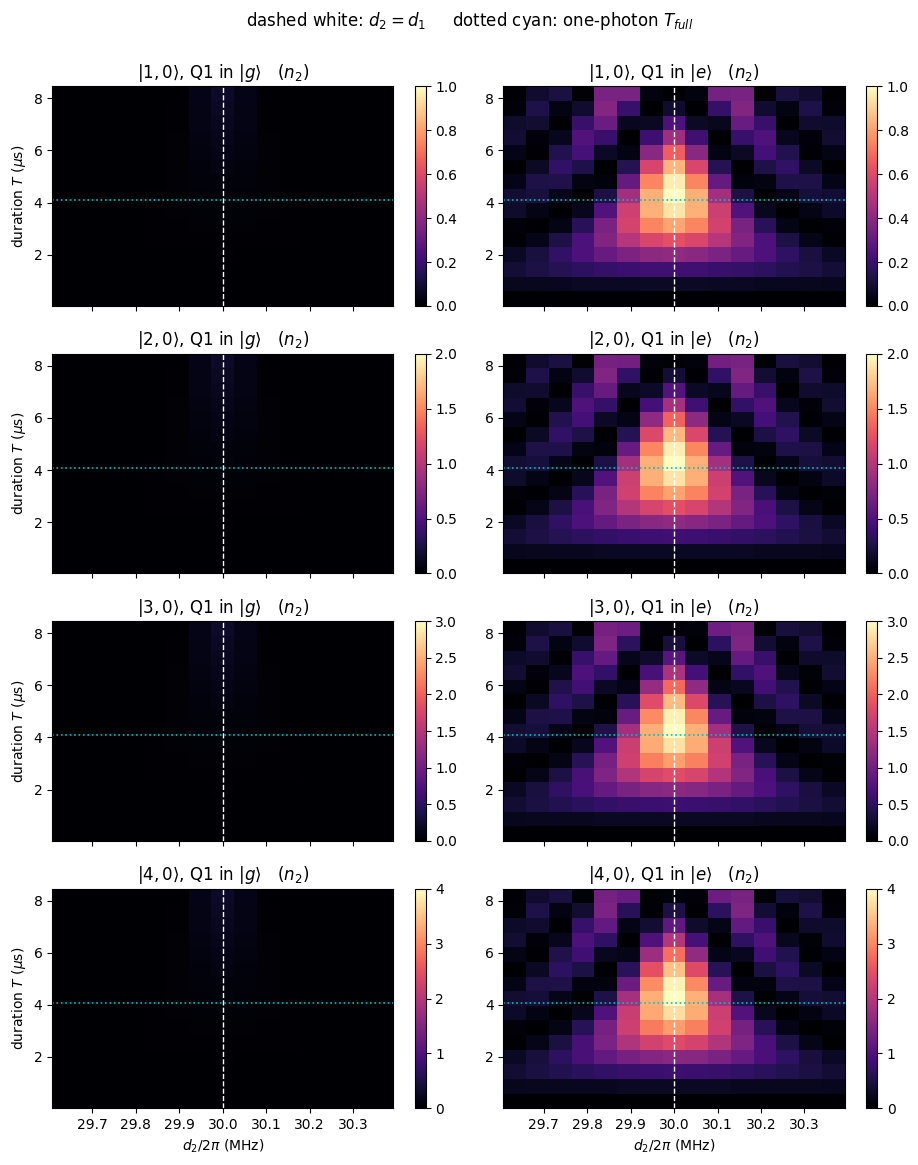

<n2>/n on resonance (d2 = d1), Q1 in |e>.  A bilinear beamsplitter predicts
identical rows: the sideband's sqrt(n) never reaches the effective beamsplitter.
   n    T=0.63Tfull  T=1.04Tfull  T=1.45Tfull  T=2.00Tfull
   1         0.62051       0.99965       0.65638       0.00711
   2         0.61459       0.99904       0.67033       0.01143
   3         0.60874       0.99823       0.68393       0.01647
   4         0.60296       0.99723       0.69717       0.02220
             0.62392       0.99984       0.64794       0.00517   <- sin^2(chi_e T_eff)


In [7]:
# ---- the chevron grid: one row per initial Fock state, columns for |g> and |e> -------
fig, ax = plt.subplots(N_FOCK, 2, figsize=(9.5, 2.9 * N_FOCK), squeeze=False, sharex=True)
for r in range(N_FOCK):
    n = r + 1                                            # this row's Fock state
    for c, name in enumerate("ge"):                      # column 0 = |g>, column 1 = |e>
        m = ax[r, c].pcolormesh(d2_list, T_list, chev[c, :, :, r], cmap="magma",
                                shading="nearest", vmin=0, vmax=n)
        ax[r, c].axvline(P1["d1"] / MHz, color="w", ls="--", lw=1)    # the resonance
        ax[r, c].axhline(T_full, color="c", ls=":", lw=1.2)           # one-photon T_full
        ax[r, c].set_title(f"$|{n},0\\rangle$, Q1 in $|{name}\\rangle$   ($n_2$)")
        fig.colorbar(m, ax=ax[r, c])
    ax[r, 0].set_ylabel("duration $T$ ($\\mu$s)")
for c in range(2):
    ax[-1, c].set_xlabel("$d_2/2\\pi$ (MHz)")
fig.suptitle("dashed white: $d_2=d_1$     dotted cyan: one-photon $T_{full}$", y=1.0)
plt.tight_layout(); plt.show()

# ---- is the exchange RATE the same for every n?  collect, then print -----------------
j0 = int(np.argmin(np.abs(d2_list - P1["d1"] / MHz)))    # the on-resonance column
picks = [int(round(f * (N_T - 1))) for f in (0.25, 0.5, 0.75, 1.0)]   # four sample times
rate_table = []
for n in range(1, N_FOCK + 1):
    rate_table.append((n, [chev[1, i, j0, n - 1] / n for i in picks]))
# A bilinear beamsplitter predicts sin^2(chi_e T_eff), independent of n.
reference = [np.sin(abs(chi_e1) * ramp_area(P1, T_list[i], 1)) ** 2 for i in picks]

# ---------------------------------- output -------------------------------------------
print("<n2>/n on resonance (d2 = d1), Q1 in |e>.  A bilinear beamsplitter predicts")
print("identical rows: the sideband's sqrt(n) never reaches the effective beamsplitter.")
print("   n  " + "".join(f"  T={T_list[i] / T_full:.2f}Tfull" for i in picks))
for n, vals in rate_table:
    print(f"   {n}  " + "".join(f"       {v:.5f}" for v in vals))
print("      " + "".join(f"       {v:.5f}" for v in reference) + "   <- sin^2(chi_e T_eff)")

### Verdict on task 1

The neck of every chevron sits on $d_2=d_1$, independent of $n$ — the "no $\chi$, every rung
degenerate" assumption behaving.

The **rate is $n$-independent too**, and the table above is the check.  It has to be: the
second-order Hamiltonian $2g^2c_kn_+$ is *bilinear* in the cavity operators, so a single
duration drives every Fock state at once.  The $\sqrt n$ of the sideband matrix element
appears in both legs of the Raman process and never reaches the effective beamsplitter.
What survives is a small **fourth-order** correction that makes high $n$ very slightly
*slower* — a couple of percent from $n=1$ to $n=4$.  That, and not any $\sqrt n$ scaling, is
what limits the fidelity-versus-photon-number curve in task 2.

The $|g\rangle$ branch is not quite dark: $\chi_g/\chi_e\approx d/2(d-\alpha)$, printed above, so it picks up a
small beamsplitter of its own.  That is not an error — it is subtracted off as part of
$\delta\chi$, and after the echo what remains of it is unconditional and free.

# Task 2 — the conditional 50:50 beamsplitter

A partial beamsplitter wants **no** conditional photon-number phase, but the rank-one lock
forces one of exactly half the beamsplitter angle — so the echo is mandatory, and the
relative pump phase flip is its active ingredient.

**What the echoed pulse makes.**  From the algebra above, with
$\bar c=(c_g+c_e)/2$ and $\delta\chi=g^2(c_e-c_g)$,

$$U_g=e^{-ig^2T\bar cN}\,e^{-i\frac{\delta\chi T}{2}G},\qquad U_e=e^{-ig^2T\bar cN}\,e^{+i\frac{\delta\chi T}{2}G}$$

The $N$ part is common, so it is a pure virtual Z.  What is left is
$\mathrm{BS}(\mp\delta\chi T)$ — a *symmetric* pair, not "$\mathrm{BS}(\theta)$ on
$|e\rangle$ and nothing on $|g\rangle$".  The two differ by an unconditional
$\mathrm{BS}(\theta/2)$, which is a real pulse and not a virtual Z, so the honest target is
the $\sigma_z$ form

$$U_\mathrm{target}=\exp\left[-i\frac{\theta}{4}\left(P_e-P_g\right)G\right]\quad\Longrightarrow\quad\mathrm{BS}(+\theta/2)\ \text{on}\ |e\rangle,\ \ \mathrm{BS}(-\theta/2)\ \text{on}\ |g\rangle$$

with conditional angle $\theta=2\delta\chi T$ between the branches, and $\theta=\pi/2$ for
50:50.  Scored against *this* target the three virtual Zs suffice and no extra cavity pulse
is needed.

**Getting to the gate we want.**  The target is $\exp[-i\frac\theta2P_eG]$, and

$$\exp\left[-i\frac{\theta}{2}P_eG\right]=\mathrm{BS}(\theta/2)\cdot\exp\left[-i\frac{\theta}{4}\left(P_e-P_g\right)G\right]$$

so one **unconditional** $\mathrm{BS}(\theta/2)$ appended to the sequence converts one into
the other.  That is a real cavity–cavity pulse, not a gauge freedom — but its angle is
exactly half the conditional angle, known in closed form with nothing fitted, and it never
touches the transmon.  Both targets are scored below.

Calibrate the one free number $T$ against the closed form, then score.

In [8]:
# ============================== TASK 2 PARAMETERS ==============================
P2 = par(Nc=NC, Nq=NQ, alpha=ALPHA, g1=G, g2=G,
         d1=D, d2=D, sigma=SIGMA, park=PARK)
THETA2 = np.pi / 2            # conditional beamsplitter angle; pi/2 is 50:50
NMAX_CAL2 = 4                 # photon range the calibration is optimised on
NMAX_LIST = [1, 2, 3, 4, 5, 6]
# ==============================================================================

T0 = gate_time(P2, THETA2, echo=True)                    # closed form, within a few percent

# The sign of the conditional angle follows from sign(dchi) and the exchange phase
# convention.  Rather than track it by hand, try both and keep the one the pulse realises.
sign_trials = []
SIGN2, F_try = None, -1.0
for sign in (+1, -1):
    trial = target_conditional_bs(P2, sign * THETA2, kind="sigmaz")
    F_s = best_virtual_z(P2, gate(P2, T0, echo=True), trial, NMAX_CAL2)[1]
    sign_trials.append((sign, F_s))
    if F_s > F_try:
        SIGN2, F_try = sign, F_s
theta2 = SIGN2 * THETA2
B2 = target_conditional_bs(P2, theta2, kind="sigmaz")    # what the echoed pulse makes


def score2(T):
    "(F, mu) for the echoed gate of duration T, scored on n1 + n2 <= NMAX_CAL2."
    mu, F = best_virtual_z(P2, gate(P2, float(T), echo=True), B2, NMAX_CAL2)
    return F, mu


# Calibrate the one free number: coarse scan about the closed form, then refine.
scan = T0 * np.linspace(0.85, 1.15, 13)
Fs = np.array([score2(T)[0] for T in scan])
i0 = int(Fs.argmax())
fine = np.linspace(scan[max(i0 - 1, 0)], scan[min(i0 + 1, len(scan) - 1)], 11)
Fs_fine = np.array([score2(T)[0] for T in fine])
T2 = float(fine[Fs_fine.argmax()])                       # the calibrated duration
F2, MU2 = score2(T2)                                     # and the frozen virtual Zs

# The gate we actually want is exp(-i theta/2 P_e G) = BS(theta/2) . (sigma_z form), so
# append one unconditional beamsplitter of half the conditional angle.  Closed form.
B2_Pe = target_conditional_bs(P2, theta2, kind="e")      # BS on |e>, identity on |g>
U2_sz = gate(P2, T2, echo=True)                          # what the pulse makes
U2_Pe = beamsplitter(P2, theta2 / 2) * U2_sz             # + the exact extra pulse
MU2_Pe, F2_Pe = best_virtual_z(P2, U2_Pe, B2_Pe, NMAX_CAL2)

U2 = virtual_z(P2, MU2_Pe) * U2_Pe                       # the P_e-form gate, fully corrected
U2_sigmaz = virtual_z(P2, MU2) * U2_sz                   # the sigma_z-form gate

# Score the SAME two gates on every subspace; only the projector changes.
rows2 = []
for nmax in NMAX_LIST:
    P = subspace_projector(P2, nmax)
    rows2.append((nmax, int(round(np.real(P.tr()))),
                  fidelity(U2, B2_Pe, P),                # vs the P_e target
                  fidelity(U2_sigmaz, B2, P)))           # vs the sigma_z target

# What the un-echoed pulse would have cost at the same conditional angle.
F_bare = best_virtual_z(P2, gate(P2, gate_time(P2, THETA2, echo=False), echo=False),
                        B2, NMAX_CAL2)[1]

# ---------------------------------- output -------------------------------------------
for sign, F_s in sign_trials:
    print(f"  trial: conditional angle {sign * THETA2 / np.pi:+.2f} pi  ->  1 - F = {1 - F_s:.3e}")
print(f"  using conditional angle {theta2 / np.pi:+.3f} pi\n")
print(f"dchi/2pi = {dchi(P2) / MHz:+.5f} MHz")
print(f"T = {T2:.4f} us  (closed form {T0:.4f}),  equivalent square top "
      f"{ramp_area(P2, T2, 2):.4f} us,  g*T = {P2['g1'] * T2:.2f}")
print(f"virtual Z (mu1, mu2, muq)/pi = {np.round(np.array(MU2) / np.pi, 4)}")
print(f"1 - F = {1 - F2:.3e}  on n1 + n2 <= {NMAX_CAL2}\n")
print(f"target exp(-i theta/2 P_e G):  unconditional BS angle theta/2 = "
      f"{theta2 / 2 / np.pi:+.4f} pi")
print(f"  virtual Z (mu1, mu2, muq)/pi = {np.round(np.array(MU2_Pe) / np.pi, 4)}")
print(f"  1 - F = {1 - F2_Pe:.3e}  on n1 + n2 <= {NMAX_CAL2}\n")
print(f"{'nmax':>6} {'D':>5} {'1-F  (P_e target)':>20} {'1-F  (sigma_z target)':>23}")
for nmax, D, F_pe, F_sz in rows2:
    print(f"{nmax:6d} {D:5d} {1 - F_pe:20.3e} {1 - F_sz:23.3e}")
print("\nThe columns are identical to every digit shown: the two targets differ by exactly")
print("BS(theta/2), so appending that one exact pulse changes the fidelity not at all.")
print("It buys the P_e form -- identity on |g> -- at the cost of one cavity pulse.")
print(f"\nsame conditional angle with NO echo:  1 - F = {1 - F_bare:.3e}")
print("That is the locked photon-number phase A = theta/2, and nothing in the gauge")
print("can absorb it.")

  trial: conditional angle +0.50 pi  ->  1 - F = 9.374e-01
  trial: conditional angle -0.50 pi  ->  1 - F = 3.888e-04
  using conditional angle -0.500 pi

dchi/2pi = -0.05556 MHz
T = 2.6775 us  (closed form 2.6250),  equivalent square top 2.3025 us,  g*T = 16.82
virtual Z (mu1, mu2, muq)/pi = [ 0.0508  0.0508 -0.    ]
1 - F = 7.463e-05  on n1 + n2 <= 4

target exp(-i theta/2 P_e G):  unconditional BS angle theta/2 = -0.2500 pi
  virtual Z (mu1, mu2, muq)/pi = [ 0.0508  0.0508 -0.    ]
  1 - F = 7.463e-05  on n1 + n2 <= 4

  nmax     D    1-F  (P_e target)   1-F  (sigma_z target)
     1     6            4.888e-05               4.888e-05
     2    12            6.426e-05               6.426e-05
     3    20            5.907e-05               5.907e-05
     4    30            7.463e-05               7.463e-05
     5    42            1.786e-04               1.786e-04
     6    56            4.630e-04               4.630e-04

The columns are identical to every digit shown: the two targets d

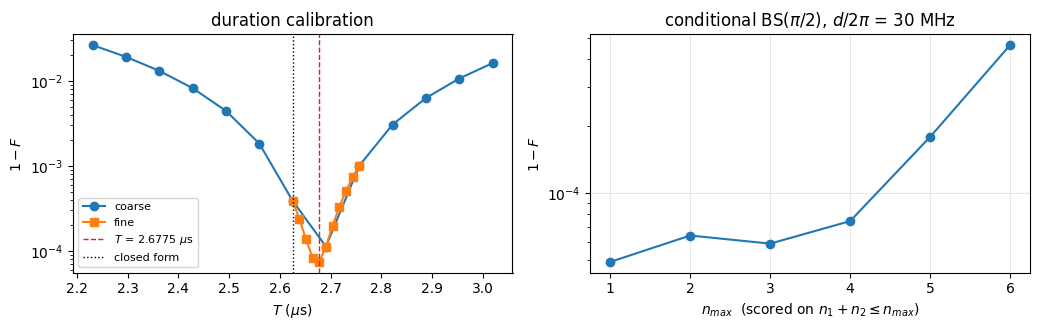

|2,1> x (|g>+|e>)/sqrt(2)  ->  state fidelity 0.999952
  out   |0,3,e>:+0.433-0.031j  |1,2,e>:-0.020-0.247j  |2,1,g>:-0.705+0.052j  |2,1,e>:+0.251-0.021j  |3,0,e>:-0.031-0.431j
  ideal |0,3,e>:-0.433+0.000j  |1,2,e>:+0.000+0.250j  |2,1,g>:+0.707+0.000j  |2,1,e>:-0.250+0.000j  |3,0,e>:+0.000+0.433j


In [9]:
# ---- left: the duration calibration.  right: fidelity versus photon number ------------
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4))
ax[0].semilogy(scan, 1 - Fs, "o-", label="coarse")               # the +-15% scan
ax[0].semilogy(fine, 1 - Fs_fine, "s-", label="fine")            # refined about the winner
ax[0].axvline(T2, color="C3", ls="--", lw=1, label=f"$T$ = {T2:.4f} $\\mu$s")
ax[0].axvline(T0, color="k", ls=":", lw=1, label="closed form")   # how good the formula is
ax[0].set_xlabel("$T$ ($\\mu$s)"); ax[0].set_ylabel("$1-F$")
ax[0].set_title("duration calibration"); ax[0].legend(fontsize=8)

ax[1].semilogy([r[0] for r in rows2], [1 - r[2] for r in rows2], "o-")   # P_e target
ax[1].set_xlabel("$n_{max}$  (scored on $n_1+n_2\\leq n_{max}$)")
ax[1].set_ylabel("$1-F$"); ax[1].grid(alpha=0.3)
ax[1].set_title(f"conditional BS($\\pi/2$), $d/2\\pi$ = {P2['d1'] / MHz:.0f} MHz")
plt.tight_layout(); plt.show()

# ---- put a state through it and look at the amplitudes -------------------------------
o2 = ops(P2)
psi = (ket(o2, 2, 1, 0) + ket(o2, 2, 1, 1)).unit()       # |2,1> x (|g>+|e>)/sqrt(2)
out = U2 * psi                                           # what the calibrated gate does
tgt = B2_Pe * psi                                        # what it should do
state_fid = abs(complex(tgt.overlap(out))) ** 2

# Collect the amplitudes above a display threshold, for both the real and ideal output.
amp_lines = []
for label, st in (("out  ", out), ("ideal", tgt)):
    parts = []
    for n1 in range(4):
        for n2 in range(4):
            for k in (0, 1):
                v = complex(ket(o2, n1, n2, k).overlap(st))
                if abs(v) > 2e-2:                        # skip numerical dust
                    parts.append(f"|{n1},{n2},{'ge'[k]}>:{v.real:+.3f}{v.imag:+.3f}j")
    amp_lines.append((label, parts))

# ---------------------------------- output -------------------------------------------
print(f"|2,1> x (|g>+|e>)/sqrt(2)  ->  state fidelity {state_fid:.6f}")
for label, parts in amp_lines:
    print(f"  {label} " + "  ".join(parts))

# Task 3 — echo variants, and the two-tone echo

Measured directly on each branch: the **photon-number phase** $A_k$ and the **beamsplitter
angle** $B_k$, from the phases of $|0,0,k\rangle$ and of the two eigenvectors
$(|1,0\rangle\pm e^{-i\Delta\phi}|0,1\rangle)/\sqrt2$ of the generator.  The conditional pair
is $(A_e-A_g,\;2(B_e-B_g))$, quoted in the
$\mathrm{BS}(\theta)=\exp(-i\tfrac\theta2G)$ convention.  The target is $(0,\ \pi/2)$.

**The obstruction.** For [half A, $T_A$] — $\pi$ — [half B, $T_B$], nulling the conditional
$N$ phase needs $T_A\delta\chi_A=T_B\delta\chi_B$, which without a phase flip kills the
beamsplitter too.  **The flip is not optional** and no choice of $g$ or $d$ substitutes.

**Two-tone.** $\delta\chi_{ef}<0$ for $d>0$ while $\delta\chi_{ge}>0$ for $d>0$, so a
two-tone echo must use **opposite-sign detunings** in its two halves to make
$T_A\delta\chi_A=T_B\delta\chi_B$ solvable with $T_A,T_B>0$.  With $|d_A|=|d_B|$ and equal
$g$ the rates match and $T_A=T_B$.  The effective rate is the harmonic mean of the two, so it
is maximal when they are equal — and then identical to the single-tone echo.  The two-tone
version is a valid *alternative*, not a speed-up.

The junction phase (the common pump phase where the frequency changes) is **not** a knob: it
is common to both pumps, so it is a transmon frame rotation that leaves $|g_j|^2$ and
$\Delta\phi$ alone, touching neither $\chi$ nor the beamsplitter.

In [10]:
# ============================== TASK 3 PARAMETERS ==============================
# This task deliberately uses BOTH parkings -- ef for half A, ge for half B -- since the
# two-tone echo is defined by that pairing.  It therefore ignores the PARK knob.
#
# Only |0,0>, |1,0> and |0,1> are probed, so a small cavity truncation is plenty and keeps
# the many propagator builds fast.  A numerics choice local to this task, not a knob.
NC_ECHO = 5

# The two halves must use OPPOSITE-SIGN detunings (see above), hence -D and +D.  Either
# sign of the knob D works: it only relabels which half is which.
pA = par(Nc=NC_ECHO, Nq=NQ, alpha=ALPHA, g1=G, g2=G, d1=-D, d2=-D,
         sigma=SIGMA, park="ef")     # half A, near e1f0
pB = par(Nc=NC_ECHO, Nq=NQ, alpha=ALPHA, g1=G, g2=G, d1=+D, d2=+D,
         sigma=SIGMA, park="ge")     # half B, near g1e0
# ==============================================================================

# Duration for a conditional BS angle of pi/2 when the two halves contribute in series.
T3 = np.pi / 2 / abs(dchi(pA) + dchi(pB)) + 4 * edge_deficit(pA)

X3 = pi_pulse(pA)                                        # the ge pi pulse, shared
sequences = {
    # no echo: one bare section, so the locked N phase survives
    "no echo (ef only)":
        lambda T, phiJ=0.0: section(pA, T),
    # single tone, WITH the phase flip: the only variant that keeps the beamsplitter
    "single-tone echo, flip":
        lambda T, phiJ=0.0: X3 * section(pA, T / 2, flip2=True) * X3 * section(pA, T / 2),
    # single tone, no flip: the pi pulse alone cancels everything, gate included
    "single-tone echo, NO flip":
        lambda T, phiJ=0.0: X3 * section(pA, T / 2) * X3 * section(pA, T / 2),
    # two tone, no flip: same story, nothing survives
    "two-tone echo, NO flip":
        lambda T, phiJ=0.0: X3 * section(pB, T / 2, phi_common=phiJ) * X3 * section(pA, T / 2),
    # two tone, with the flip: works, but at the harmonic-mean rate of its two halves
    "two-tone echo, flip":
        lambda T, phiJ=0.0: X3 * section(pB, T / 2, flip2=True, phi_common=phiJ)
                            * X3 * section(pA, T / 2),
}

# Measure (A, 2B) for every variant at the one duration T3.
variant_rows = [(name, *conditional_angles(pA, build(T3))) for name, build in sequences.items()]

# The junction phase is the common pump phase where the frequency changes.  Scan it: if it
# mattered, the two-tone echo would need it tuned.
phis = np.linspace(0, 2 * np.pi, 13)
jscan = np.array([conditional_angles(pA, sequences["two-tone echo, flip"](T3, f))
                  for f in phis])

# ---------------------------------- output -------------------------------------------
print(f"dchi_A (ef @ {-D / MHz:+.0f} MHz)/2pi = {dchi(pA) / MHz:+.4f} MHz")
print(f"dchi_B (ge @ {+D / MHz:+.0f} MHz)/2pi = {dchi(pB) / MHz:+.4f} MHz"
      f"   -> same sign, so T_A = T_B works")
print(f"duration for a conditional BS angle of pi/2:  T = {T3:.4f} us\n")
print(f"{'variant':>28} {'cond. N phase':>16} {'cond. BS angle':>16}")
for name, A, theta in variant_rows:
    print(f"{name:>28} {A / np.pi:15.5f}pi {theta / np.pi:15.5f}pi")
print("\nTarget is (0, 0.5 pi).  Un-echoed, the N phase is exactly HALF the BS angle:")
print("the rank-one lock, untunable in g or d.  Both echoes null it; without the phase")
print("flip the beamsplitter cancels along with it and there is no gate at all.")
print(f"\njunction-phase scan: N phase spread {np.ptp(np.abs(jscan[:, 0])) / np.pi:.2e} pi,"
      f"  BS angle spread {np.ptp(np.abs(jscan[:, 1])) / np.pi:.2e} pi   -> flat, as argued")

dchi_A (ef @ -9 MHz)/2pi = +0.2386 MHz
dchi_B (ge @ +9 MHz)/2pi = +0.2386 MHz   -> same sign, so T_A = T_B works
duration for a conditional BS angle of pi/2:  T = 0.8989 us

                     variant    cond. N phase   cond. BS angle
           no echo (ef only)         0.32692pi         0.65385pi
      single-tone echo, flip         0.00000pi         0.48915pi
   single-tone echo, NO flip         0.00000pi         0.00000pi
      two-tone echo, NO flip        -0.00000pi         0.00000pi
         two-tone echo, flip        -0.00000pi         0.48915pi

Target is (0, 0.5 pi).  Un-echoed, the N phase is exactly HALF the BS angle:
the rank-one lock, untunable in g or d.  Both echoes null it; without the phase
flip the beamsplitter cancels along with it and there is no gate at all.

junction-phase scan: N phase spread 3.23e-14 pi,  BS angle spread 7.79e-14 pi   -> flat, as argued


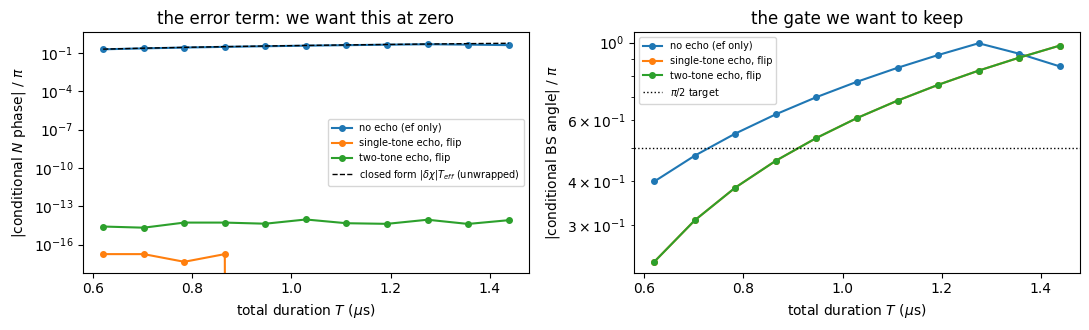

In [11]:
# sweep the duration: is the cancellation structural, or a coincidence at one T?
Ts3 = np.linspace(8 * pA["sigma"] + 0.02, 1.6 * T3, 11)
show = ["no echo (ef only)", "single-tone echo, flip", "two-tone echo, flip"]
sweep = {}
for name in show:
    rows = []
    for T in Ts3:
        rows.append(conditional_angles(pA, sequences[name](float(T), 0.0)))
    sweep[name] = np.array(rows)

# The un-echoed A grows past pi/2 and is then wrapped by the mod-pi extraction, so
# plot the closed form beside it: |A| = |dchi| T_eff, unwrapped.
A_closed = []
for T in Ts3:
    A_closed.append(abs(dchi(pA) * ramp_area(pA, float(T), 1)))
A_closed = np.array(A_closed)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for name, c in sweep.items():
    ax[0].plot(Ts3, np.abs(c[:, 0]) / np.pi, "o-", ms=4, label=name)
    ax[1].plot(Ts3, np.abs(c[:, 1]) / np.pi, "o-", ms=4, label=name)
ax[0].plot(Ts3, A_closed / np.pi, "k--", lw=1,
           label="closed form $|\\delta\\chi| T_{eff}$ (unwrapped)")
ax[0].set_ylabel("|conditional $N$ phase| / $\\pi$")
ax[0].set_title("the error term: we want this at zero")
ax[1].set_ylabel("|conditional BS angle| / $\\pi$")
ax[1].axhline(0.5, color="k", ls=":", lw=1, label="$\\pi/2$ target")
ax[1].set_title("the gate we want to keep")
for a in ax:
    a.set_xlabel("total duration $T$ ($\\mu$s)"); a.set_yscale("log"); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

# Task 4 — decoherence, and trading detuning against gate time

Coherence times, all in µs:

$$T_1^\mathrm{cav}=500,\qquad T_2^\mathrm{cav}=700,\qquad T_1^q=200,\qquad T_2^q=80$$

A $T_2$ is the *total* dephasing time, so the pure-dephasing rate is whatever is left once
relaxation has taken its share:

$$\frac{1}{T_\phi}=\frac{1}{T_2}-\frac{1}{2T_1}\qquad\Longrightarrow\qquad T_\phi^\mathrm{cav}=2333\ \mu s,\qquad T_\phi^q=100\ \mu s$$

Dephasing of an oscillator couples to its photon number, so the six Lindblad operators are
$\sqrt{\kappa}\,a_1$, $\sqrt{\kappa}\,a_2$, $\sqrt{\gamma}\,q$ and
$\sqrt{1/T_\phi}\times(n_1,n_2,n_q)$.

### Method: `qutip.mesolve`, averaged over random states

$$F=\left\langle\;\left\langle\psi_\mathrm{ideal}\right|\rho_\mathrm{out}\left|\psi_\mathrm{ideal}\right\rangle\;\right\rangle_{\psi\ \mathrm{Haar}},\qquad\left|\psi_\mathrm{ideal}\right\rangle=U_\mathrm{target}\left|\psi\right\rangle$$

$\rho_\mathrm{out}$ comes from `mesolve` on the real ramped, echoed pulse, so it carries the
decoherence **and** every coherent error at once — no perturbative expansion anywhere.  Two
practical notes:

* `nsteps` must be pushed to $2\times10^5$. The Hamiltonian spans ~3 GHz while the gate takes
  microseconds, so the integrator needs ~$10^5$ steps and gives up at the default 2500.
* the Hann envelope is handed to `mesolve` as a time-dependent coefficient, so the solver
  picks its own step size rather than inheriting our slicing.

### Why $n_\mathrm{max}\le4$ and $N_c=5$

Haar-random inputs make $\rho$ **dense**, and mesolve then costs ~250 s per state at
$N_c=9$ — the full grid would run for about 18 hours.  At $N_c=5$ (Fock 0…4, dim 75) it is
seconds per state, so the sweep is honest end-to-end master-equation numbers rather than an
expansion.  The price is that $n_\mathrm{max}$ stops at 4 — the most $N_c=5$ can hold, since
$|4,0\rangle$ needs Fock level 4.  $|h\rangle$ is dropped too
($N_q=3$), since it is only reached virtually at amplitude $g/(d+\alpha)\sim1\%$.

The **ideal** panel is the same gate scored with the exact unitary at the same truncation, so
the two plots differ only by the master equation.

### The trade-off being swept

Shrinking $d$ raises $\delta\chi=2g^2\alpha/(d(d-\alpha))$, so the gate gets **shorter** and
collects less decoherence — but $|g/d|$ grows, so the adiabatic elimination degrades and the
**coherent** error rises.  Somewhere in between is the best total.

The ramp is deliberately **longer and fixed** at $\sigma=150$ ns: a small $d$ needs a slow
ramp to keep the transmon adiabatic ($\sigma|d|\gg1$), and fixing it means only one thing
changes across the sweep.

### The calibration, step by step

Run identically at every detuning, in the order a device would:

1. **closed-form rate** — $\delta\chi=2g^2\alpha/(d(d-\alpha))$, no simulation;
2. **closed-form duration** — $T_0$ with $2|\delta\chi|T_\mathrm{eff}=\theta$, ramp deficit added back;
3. **fix the sign** of the target angle by trying $\pm\theta$ and keeping the better;
4. **scan $T$** about $T_0$ — coarse $\pm8\%$, then fine — maximising the projected fidelity over the three virtual Zs at $n_\mathrm{max}=4$;
5. **freeze** $T$ and the virtual-Z triple; nothing afterwards is re-fitted.

Then one gate per detuning is scored on the projectors $n_\mathrm{max}=2$ and $4$.  Each
Haar state costs ~18 s, so the grid is deliberately small: 4 detunings $\times$ 2 subspaces
$\times$ 3 states $\approx$ 7 minutes.  The state-to-state spread is plotted as error bars, so
the sampling error is visible rather than hidden.

In [12]:
# ================== DECOHERENCE SWEEP: PARAMETERS ==================
T1_CAV, T2_CAV = 500.0, 700.0     # cavity relaxation / total dephasing time, us
T1_Q,   T2_Q   = 200.0,  80.0     # transmon relaxation / total dephasing time, us

SIGMA_SWEEP  = 0.15               # LONGER, FIXED ramp: each edge lasts 2*sigma = 0.30 us
NC_SWEEP     = 5                  # Fock 0..4: small enough for dense-rho mesolve
NQ_SWEEP     = 3                  # |g>, |e>, |f>; |h> dropped (reached only virtually)
NSLICE_SWEEP = 60                 # slices per edge, for the unitary calibration only
MESOLVE_STEPS = 200000            # nsteps for mesolve; the default 2500 fails outright
D_SWEEP_MHz  = [30, 20, 15, 10]   # detunings to try, getting SMALLER
NMAX_SCORE   = [2, 4]             # subspaces to score; each costs ~18 s per state
N_STATES     = 3                  # Haar states per point.  Runtime = 4*2*3*18 s ~ 7 min
NMAX_CAL     = 4                  # the one subspace the calibration optimises on
THETA_TGT    = np.pi / 2          # target conditional beamsplitter angle (50:50)
SEED         = 12345              # fixed, so the random states are reproducible

# The fixed-total-N scan below needs Fock 0..8, hence its own larger truncation.  Kept
# deliberately small: 4 sectors x 2 states at ONE detuning is ~8 gate solves, a few minutes.
NC_FIXED     = 9                  # Fock 0..8, so N_total = 8 fits
FIXED_N_LIST = [2, 4, 6, 8]       # total photon numbers to scan
N_STATES_FIX = 2                  # Haar states per sector (enough for an error bar)
# ===================================================================


def collapse_ops(p):
    """
    The six Lindblad operators.  A T2 is the *total* dephasing time, so the pure-dephasing
    rate is what is left after relaxation:  1/T_phi = 1/T2 - 1/(2 T1).  Dephasing of an
    oscillator couples to its photon number, hence n1, n2, nq.
    """
    o = ops(p)
    rate_cav = 1.0 / T1_CAV                              # cavity photon loss
    rate_q = 1.0 / T1_Q                                  # transmon relaxation
    deph_cav = 1.0 / T2_CAV - 1.0 / (2 * T1_CAV)         # cavity pure dephasing
    deph_q = 1.0 / T2_Q - 1.0 / (2 * T1_Q)               # transmon pure dephasing
    return [np.sqrt(rate_cav) * o["a1"], np.sqrt(rate_cav) * o["a2"],
            np.sqrt(rate_q) * o["q"],
            np.sqrt(deph_cav) * o["n1"], np.sqrt(deph_cav) * o["n2"],
            np.sqrt(deph_q) * o["nq"]]


def mesolve_section(p, state, T, flip2, cs):
    """
    One ramped section under the Lindblad master equation, via qutip.mesolve.

    The Hann envelope is passed as a time-dependent coefficient rather than sliced, so the
    solver chooses its own steps.  nsteps must be far above the default: H spans ~3 GHz
    while T is microseconds, so ~1e5 steps are needed and 2500 raises IntegratorException.
    """
    W = 2 * p["sigma"]                                   # one edge lasts 2 sigma
    H_off = hamiltonian(p, drive=False)                  # drive off
    dH = hamiltonian(p, flip2=flip2) - H_off             # the drive alone

    def envelope_of_t(t, args):                          # rise, flat top, fall
        if t < W:
            return np.sin(np.pi * (t / W) / 2) ** 2      # Hann rise
        if t > T - W:
            return np.cos(np.pi * ((t - (T - W)) / W) / 2) ** 2   # Hann fall
        return 1.0                                       # flat top

    out = qt.mesolve([H_off, [dH, envelope_of_t]], state, [0.0, T], c_ops=cs,
                     options=dict(nsteps=MESOLVE_STEPS, atol=1e-9, rtol=1e-7))
    return out.states[-1]                                # density matrix at the end


def mesolve_gate(p, T, state, cs):
    "The echoed gate under the master equation: sec, pi, sec with phi2 flipped, pi."
    X = pi_pulse(p)                                      # instantaneous, applied directly
    rho = mesolve_section(p, state, T / 2, False, cs)     # first half
    rho = X * rho * X.dag()                              # pi pulse
    rho = mesolve_section(p, rho, T / 2, True, cs)        # second half, pump 2 inverted
    return X * rho * X.dag()                             # closing pi pulse


def random_subspace_states(p, nmax, n_states, seed):
    "Haar-random kets supported on the n1 + n2 <= nmax, transmon-in-{g,e} subspace."
    rng = np.random.default_rng(seed)
    o = ops(p)
    idx = subspace_index(p, nmax)                        # the allowed basis states
    out = []
    for _ in range(n_states):
        amp = rng.normal(size=len(idx)) + 1j * rng.normal(size=len(idx))   # complex Gaussian
        vec = np.zeros(o["dim"], dtype=complex)
        vec[idx] = amp / np.linalg.norm(amp)             # normalise -> Haar on the subspace
        out.append(qt.Qobj(vec.reshape(-1, 1), dims=[o["n1"].dims[0], [1, 1, 1]]))
    return out


def average_fidelity(p, T, U_target, correction, nmax, cs, n_states, seed):
    """
    <F> over Haar-random inputs, F = <psi_ideal| rho_out |psi_ideal>, from mesolve.

    `correction` is the frozen virtual Z times the compensating BS(theta/2) -- the known,
    closed-form corrections, applied to the output exactly as they would be on a device.
    Returns (mean F, std F, mean trace) -- the trace is a solver sanity check.
    """
    fids, traces = [], []
    for psi in random_subspace_states(p, nmax, n_states, seed):
        rho = mesolve_gate(p, T, psi, cs)                # the real, noisy gate
        rho = correction * rho * correction.dag()        # apply the known corrections
        psi_ideal = U_target * psi                       # where it should have landed
        fids.append(float(np.real((psi_ideal.dag() * rho * psi_ideal))))
        traces.append(float(np.real(rho.tr())))
    return float(np.mean(fids)), float(np.std(fids)), float(np.mean(traces))


def fixed_N_states(p, N_total, n_states, seed):
    """
    Haar-random kets on the sector of FIXED total photon number N_total, transmon in {g,e}.

    That sector has dimension 2*(N_total + 1): the cavity splittings |n, N-n> times two
    transmon levels.  The ideal conditional beamsplitter conserves n1 + n2, so the sector is
    closed under the gate -- anything that leaks out of it came from decoherence.  It is also
    cheap for mesolve, since rho stays localised instead of filling the whole space.
    """
    o = ops(p)
    rng = np.random.default_rng(seed)
    idx = []
    for k in (0, 1):                                     # transmon g, then e
        for n1 in range(N_total + 1):                    # all splittings of N_total
            idx.append(index(o, n1, N_total - n1, k))
    out = []
    for _ in range(n_states):
        amp = rng.normal(size=len(idx)) + 1j * rng.normal(size=len(idx))
        vec = np.zeros(o["dim"], dtype=complex)
        vec[idx] = amp / np.linalg.norm(amp)             # Haar on the sector
        out.append(qt.Qobj(vec.reshape(-1, 1), dims=[o["n1"].dims[0], [1, 1, 1]]))
    return out, len(idx)


def calibrate_gate(p, theta_target, nmax_cal):
    """
    Steps 1-5 of the calibration (see the markdown above).  Returns (T, mu, theta).
    """
    T0 = gate_time(p, theta_target, echo=True)           # STEPS 1-2: closed form

    # STEP 3: the sign of the conditional angle follows from sign(dchi) and the exchange
    # phase convention; try both rather than tracking it by hand.
    best_sign, best_F = +1, -1.0
    for sign in (+1, -1):
        trial = target_conditional_bs(p, sign * theta_target, kind="sigmaz")
        F = best_virtual_z(p, gate(p, T0, echo=True), trial, nmax_cal)[1]
        if F > best_F:
            best_sign, best_F = sign, F
    theta = best_sign * theta_target
    target_sz = target_conditional_bs(p, theta, kind="sigmaz")   # what the pulse makes

    def score(T):
        return best_virtual_z(p, gate(p, float(T), echo=True), target_sz, nmax_cal)[1]

    # STEP 4a: coarse scan, +-8% about the closed form.
    coarse = T0 * np.linspace(0.92, 1.08, 9)
    F_coarse = np.array([score(T) for T in coarse])
    i_best = int(F_coarse.argmax())

    # STEP 4b: fine scan between the coarse winner's two neighbours.
    fine = np.linspace(coarse[max(i_best - 1, 0)],
                       coarse[min(i_best + 1, len(coarse) - 1)], 9)
    F_fine = np.array([score(T) for T in fine])
    T = float(fine[int(F_fine.argmax())])

    # STEP 5: freeze the virtual Zs at the chosen T.
    mu, _ = best_virtual_z(p, gate(p, T, echo=True), target_sz, nmax_cal)
    return T, mu, theta


# ---- run the sweep: compute everything, print at the end ----------------------------
t_start = time.time()                                    # so the cost is visible
sweep_rows = []                                          # one entry per (detuning, n_max)
sweep_log = []                                           # one diagnostic line per detuning

for d_MHz in D_SWEEP_MHz:
    p = par(Nc=NC_SWEEP, Nq=NQ_SWEEP, alpha=ALPHA, g1=G, g2=G,
            d1=d_MHz * MHz, d2=d_MHz * MHz,
            sigma=SIGMA_SWEEP, n_slice=NSLICE_SWEEP, park=PARK)
    cs = collapse_ops(p)                                 # the six Lindblad operators

    T, mu, theta = calibrate_gate(p, THETA_TGT, NMAX_CAL)    # steps 1-5

    # The known corrections, and the gate we actually want (identity on |g>).
    correction = virtual_z(p, mu) * beamsplitter(p, theta / 2)
    U_target = target_conditional_bs(p, theta, kind="e")

    # IDEAL: the same gate as an exact unitary, no master equation.
    U_ideal = correction * gate(p, T, echo=True)

    for nmax in NMAX_SCORE:
        P = subspace_projector(p, nmax)                  # same gate, different subspace
        D = float(np.real(P.tr()))

        coherent = 1.0 - fidelity(U_ideal, U_target, P)  # process infidelity, unitary only
        # convert to an average-state infidelity so it is comparable with mesolve
        coherent_avg = D / (D + 1) * coherent

        mean_F, std_F, tr = average_fidelity(p, T, U_target, correction,
                                             nmax, cs, N_STATES, SEED)
        sweep_rows.append(dict(d=d_MHz, nmax=nmax, T=T, D=D,
                               ideal=coherent_avg, noisy=1.0 - mean_F,
                               std=std_F, trace=tr))

    # |g/d| << 1 is what second order needs; sigma*|d| >> 1 is what the ramp needs.
    sweep_log.append(f"{d_MHz:7d} {dchi(p) / MHz:+11.4f} {T:9.4f} "
                     f"{ramp_area(p, T, 2):11.3f} {abs(G / (d_MHz * MHz)):8.3f} "
                     f"{SIGMA_SWEEP * abs(d_MHz * MHz):9.1f}")

# ---------------------------------- output -------------------------------------------
print(f"T_phi cavity = {1 / (1 / T2_CAV - 1 / (2 * T1_CAV)):7.0f} us      "
      f"T_phi transmon = {1 / (1 / T2_Q - 1 / (2 * T1_Q)):5.0f} us")
print(f"mesolve on dim {ops(par(Nc=NC_SWEEP, Nq=NQ_SWEEP))['dim']} "
      f"({N_STATES} Haar states per point), fixed ramp sigma = {SIGMA_SWEEP * 1000:.0f} ns\n")
print(f"{'d/2pi':>7} {'dchi/2pi':>11} {'T (us)':>9} {'flat top':>11} {'|g/d|':>8} "
      f"{'sigma*d':>9}")
for line in sweep_log:
    print(line)
print(f"\nmesolve sweep took {time.time() - t_start:.0f} s "
      f"({len(D_SWEEP_MHz) * len(NMAX_SCORE) * N_STATES} gate solves)")

T_phi cavity =    2333 us      T_phi transmon =   100 us
mesolve on dim 75 (3 Haar states per point), fixed ramp sigma = 150 ns

  d/2pi    dchi/2pi    T (us)    flat top    |g/d|   sigma*d
     30     -0.0556    3.0300       2.280    0.033      28.3
     20     -0.0882    2.2100       1.460    0.050      18.8
     15     -0.1212    1.8347       1.085    0.067      14.1
     10     -0.1875    1.4804       0.730    0.100       9.4

mesolve sweep took 306 s (24 gate solves)


  d/2pi  n_max    D   T (us)    ideal 1-F   mesolve 1-F        std    tr rho
     30      2   12   3.0300    2.082e-04     2.843e-02   3.94e-03  1.000000
     30      4   30   3.0300    3.180e-03     3.721e-02   1.82e-03  1.000000
     20      2   12   2.2100    1.044e-04     2.068e-02   2.76e-03  1.000000
     20      4   30   2.2100    1.653e-03     2.677e-02   1.13e-03  1.000000
     15      2   12   1.8347    1.757e-04     1.730e-02   2.23e-03  1.000000
     15      4   30   1.8347    1.281e-03     2.231e-02   8.33e-04  1.000000
     10      2   12   1.4804    6.133e-04     1.452e-02   1.78e-03  1.000000
     10      4   30   1.4804    1.659e-03     1.885e-02   5.57e-04  1.000000

best at n_max = 4:  d/2pi = 10 MHz,  T = 1.4804 us,  1 - <F> = 1.885e-02
decoherence costs a factor 11 over the ideal gate at that point


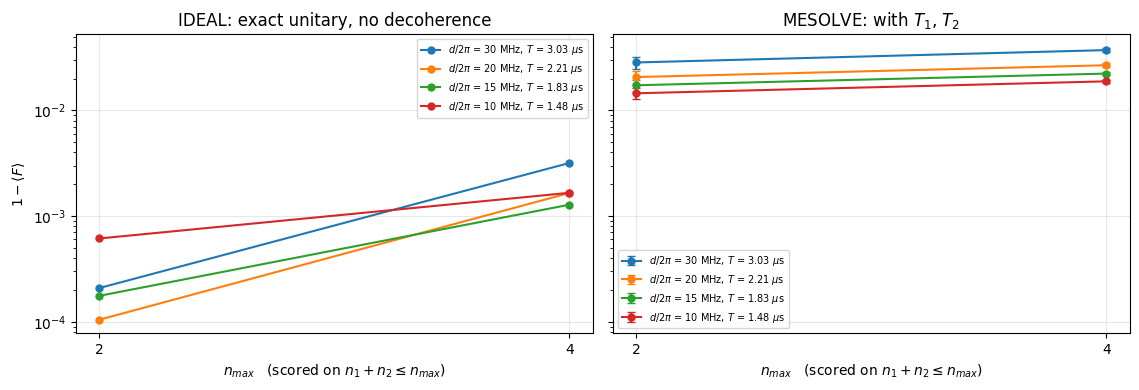

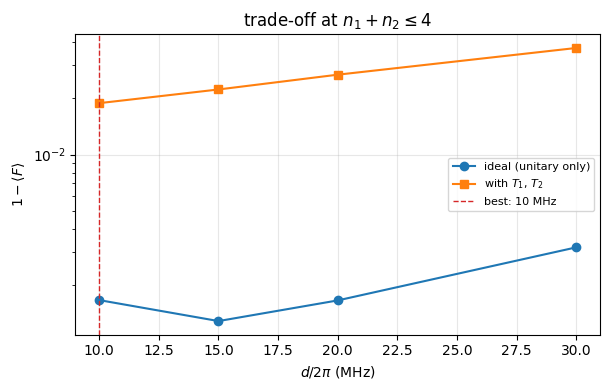


fixed total photon number, d/2pi = 10 MHz, T = 1.4804 us, Nc = 9, 2 states per sector
 N_total  sector dim    ideal 1-F   mesolve 1-F        std
       2           6    6.449e-04     1.392e-02   3.89e-04
       4          10    1.634e-03     2.348e-02   7.19e-04
       6          14    1.183e-02     4.067e-02   1.41e-03
       8          18    6.594e-02     1.010e-01   1.18e-04
took 354 s (8 gate solves)


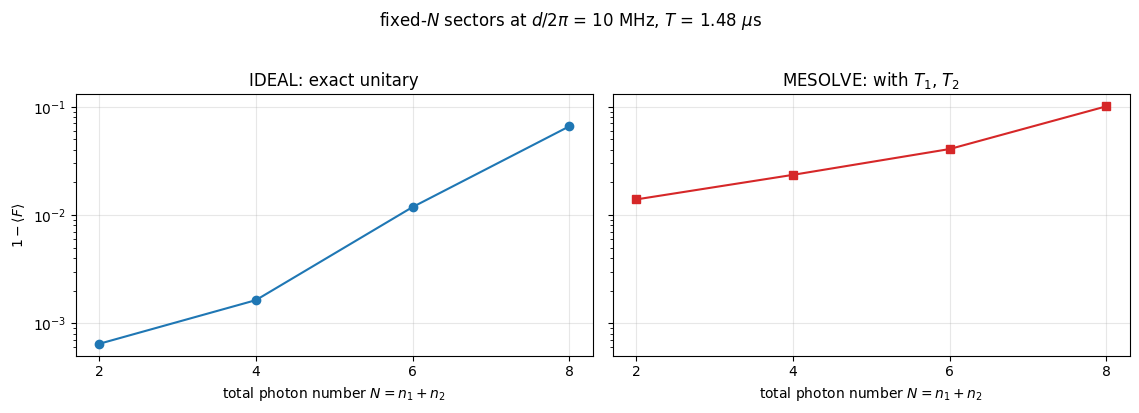

In [13]:
# ---- the table: ideal versus master equation, at every subspace ----------------------
print(f"{'d/2pi':>7} {'n_max':>6} {'D':>4} {'T (us)':>8} {'ideal 1-F':>12} "
      f"{'mesolve 1-F':>13} {'std':>10} {'tr rho':>9}")
for r in sweep_rows:
    print(f"{r['d']:7d} {r['nmax']:6d} {r['D']:4.0f} {r['T']:8.4f} {r['ideal']:12.3e} "
          f"{r['noisy']:13.3e} {r['std']:10.2e} {r['trace']:9.6f}")

# The best detuning, judged on the largest subspace we can afford here.
largest = [r for r in sweep_rows if r["nmax"] == NMAX_SCORE[-1]]
best = min(largest, key=lambda r: r["noisy"])
print(f"\nbest at n_max = {NMAX_SCORE[-1]}:  d/2pi = {best['d']} MHz,  T = {best['T']:.4f} us,"
      f"  1 - <F> = {best['noisy']:.3e}")
print(f"decoherence costs a factor {best['noisy'] / best['ideal']:.0f} over the ideal gate"
      f" at that point")

# ---- two plots: ideal on the left, master equation on the right ----------------------
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0), sharey=True)
for d_MHz in D_SWEEP_MHz:                                # one curve per detuning
    rows = [r for r in sweep_rows if r["d"] == d_MHz]     # its three subspaces
    n_axis = [r["nmax"] for r in rows]
    lab = f"$d/2\\pi$ = {d_MHz} MHz, $T$ = {rows[0]['T']:.2f} $\\mu$s"
    ax[0].semilogy(n_axis, [r["ideal"] for r in rows], "o-", ms=5, label=lab)
    ax[1].errorbar(n_axis, [r["noisy"] for r in rows],    # error bars = state-to-state std
                   yerr=[r["std"] for r in rows], fmt="o-", ms=5, capsize=3, label=lab)
ax[1].set_yscale("log")
ax[0].set_title("IDEAL: exact unitary, no decoherence")
ax[1].set_title("MESOLVE: with $T_1$, $T_2$")
for a in ax:
    a.set_xlabel("$n_{max}$   (scored on $n_1+n_2\\leq n_{max}$)")
    a.set_xticks(NMAX_SCORE)
    a.grid(alpha=0.3)
    a.legend(fontsize=7)
ax[0].set_ylabel("$1-\\langle F\\rangle$")
plt.tight_layout(); plt.show()

# ---- the trade-off head on: both against detuning, at the largest subspace -----------
fig, ax = plt.subplots(figsize=(6.2, 4.0))
d_axis = [r["d"] for r in largest]
ax.semilogy(d_axis, [r["ideal"] for r in largest], "o-", label="ideal (unitary only)")
ax.semilogy(d_axis, [r["noisy"] for r in largest], "s-", label="with $T_1$, $T_2$")
ax.axvline(best["d"], color="C3", ls="--", lw=1, label=f"best: {best['d']} MHz")
ax.set_xlabel("$d/2\\pi$ (MHz)"); ax.set_ylabel("$1-\\langle F\\rangle$")
ax.set_title(f"trade-off at $n_1+n_2\\leq{NMAX_SCORE[-1]}$")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ---- fixed total photon number, up to N = 8, at the best detuning ---------------------
# A fixed-N sector is closed under the ideal gate, so this isolates how the error grows
# with photon number.  It needs Fock 0..8, hence NC_FIXED = 9 -- a bigger space than the
# sweep above, which is affordable only because rho stays inside a small sector.
t_fix = time.time()
p_fix = par(Nc=NC_FIXED, Nq=NQ_SWEEP, alpha=ALPHA, g1=G, g2=G,
            d1=best["d"] * MHz, d2=best["d"] * MHz,
            sigma=SIGMA_SWEEP, n_slice=NSLICE_SWEEP, park=PARK)
cs_fix = collapse_ops(p_fix)

# Recalibrate at this truncation: the gate is the same, but T is re-optimised here.
T_fix, mu_fix, theta_fix = calibrate_gate(p_fix, THETA_TGT, 4)
corr_fix = virtual_z(p_fix, mu_fix) * beamsplitter(p_fix, theta_fix / 2)
U_tgt_fix = target_conditional_bs(p_fix, theta_fix, kind="e")
U_ideal_fix = corr_fix * gate(p_fix, T_fix, echo=True)   # the ideal, unitary version

fixed_rows = []
for N_total in FIXED_N_LIST:
    states, d_sector = fixed_N_states(p_fix, N_total, N_STATES_FIX, SEED)

    fids_ideal, fids_noisy = [], []
    for psi in states:
        psi_ideal = U_tgt_fix * psi                      # where it should land

        # ideal: the exact unitary, no master equation
        out_u = U_ideal_fix * psi
        fids_ideal.append(abs(complex(psi_ideal.overlap(out_u))) ** 2)

        # noisy: the same gate under mesolve, then the same known corrections
        rho = mesolve_gate(p_fix, T_fix, psi, cs_fix)
        rho = corr_fix * rho * corr_fix.dag()
        fids_noisy.append(float(np.real((psi_ideal.dag() * rho * psi_ideal))))

    fixed_rows.append(dict(N=N_total, dim=d_sector,
                           ideal=1 - float(np.mean(fids_ideal)),
                           noisy=1 - float(np.mean(fids_noisy)),
                           std=float(np.std(fids_noisy))))
t_fix = time.time() - t_fix

# ---------------------------------- output -------------------------------------------
print(f"\nfixed total photon number, d/2pi = {best['d']} MHz, T = {T_fix:.4f} us, "
      f"Nc = {NC_FIXED}, {N_STATES_FIX} states per sector")
print(f"{'N_total':>8} {'sector dim':>11} {'ideal 1-F':>12} {'mesolve 1-F':>13} {'std':>10}")
for r in fixed_rows:
    print(f"{r['N']:8d} {r['dim']:11d} {r['ideal']:12.3e} {r['noisy']:13.3e} {r['std']:10.2e}")
print(f"took {t_fix:.0f} s ({len(FIXED_N_LIST) * N_STATES_FIX} gate solves)")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0), sharey=True)
N_axis = [r["N"] for r in fixed_rows]
ax[0].semilogy(N_axis, [r["ideal"] for r in fixed_rows], "o-", ms=6, color="C0")
ax[1].errorbar(N_axis, [r["noisy"] for r in fixed_rows],
               yerr=[r["std"] for r in fixed_rows], fmt="s-", ms=6, capsize=3, color="C3")
ax[1].set_yscale("log")
ax[0].set_title("IDEAL: exact unitary")
ax[1].set_title("MESOLVE: with $T_1$, $T_2$")
for a_ in ax:
    a_.set_xlabel("total photon number $N=n_1+n_2$")
    a_.set_xticks(FIXED_N_LIST); a_.grid(alpha=0.3)
ax[0].set_ylabel("$1-\\langle F\\rangle$")
fig.suptitle(f"fixed-$N$ sectors at $d/2\\pi$ = {best['d']} MHz, "
             f"$T$ = {T_fix:.2f} $\\mu$s", y=1.02)
plt.tight_layout(); plt.show()